# Order Generator

This notebook develops a pipeline for generating realistic daily order counts per region.
It takes pre-computed distances (from `distance_generator.ipynb`), SKU weights
(from `weight_generator.ipynb`), and costs (from `cost_generator.ipynb`) as inputs and
produces synthetic order count series $N_{r,t}$ that preserve region-specific intensity,
weekday/monthly seasonality, cross-region co-movement, region-specific persistence,
and the overdispersion typical of count data via a Negative Binomial model.

### Pipeline overview

| Step | Description | Output |
|------|-------------|--------|
| **1** | Setup and Data Loading | - |
| **2** | Exploratory Data Analysis | - |
| **3** | Build calendar covariates | Design matrix $X_t$ |
| **3A** | ARIMA baseline forecast | Per-region ARIMA fit + forecast |
| **4** | Fit per-region seasonality via NB-GLM | Fitted seasonal component $\hat S_r(t)$ |
| **5** | Construct seasonality-adjusted panel for PCA | Residual panel $\tilde Y$ |
| **6** | Extract shared latent factors via PCA | Factors $\hat u_t$, loadings $\hat\beta_r$ |
| **7** | Model factor dynamics via VAR | VAR coefficients $(A, \Sigma_\eta)$ |
| **8** | Fit full NB-GLM (seasonality + factors) per region | Coefficients + dispersion $\kappa_r$ |
| **9** | Add region-specific persistence (latent AR) | AR parameters $(\phi_r, \sigma_r^2)$ |
| **10** | End-to-end generation procedure | Synthetic order counts $N_{r,t}$ |
| **11** | Testing and Validation | - |

## 1. Setup & Data Loading

### 1.1 Configuration

In [30]:
# CONFIGURATION

# Seed
SEED = 42

# Data path
RAW_DATA_PATH = "../../../data_files/raw"

# Output paths
OUTPUTS_PATH = "outputs/intermediate"
MODELS_PATH = "outputs/generated_models"

# Network dimensions (must match preceding generators)
n_regions = 10
n_warehouses = 10
n_skus = 10

# Variance-stabilizing constant for log transform (PCA step only)
VS_CONSTANT = 1.0

# Number of PCA factors to retain
N_FACTORS = 5

# Number of Fourier harmonics for annual seasonality (0 = disable)
N_FOURIER_HARMONICS = 2

# Annual seasonality period (days)
FOURIER_PERIOD = 365

# VAR model order
VAR_ORDER = 1

# Persistence model: 'latent_ar' (Option B)
PERSISTENCE_MODEL = "latent_ar"

# AR damping: fraction of estimated innovation variance to retain.
# The raw σ² from log-ratio residuals includes NB sampling noise that the NB
# will regenerate during simulation.  Keeping only a fraction avoids
# double-counting overdispersion.
AR_DAMPING = 0.05

# Hard clamp on the latent AR state to prevent tail explosions.
# exp(0.5) ≈ 1.65, so the AR can shift the mean by at most ±65%.
V_CLAMP = 0.5

# Generation horizon (days)
T_GENERATE = 387

# Number of synthetic samples for validation
N_SYNTHETIC_RUNS = 10

# ARIMA baseline
ARIMA_TRAIN_FRAC = 0.8
N_TOP_ARIMA = 6
ARIMA_MIN_MEAN = 0.5

### 1.2 Imports & Data Loading

In [31]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.api import VAR as VARModel
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

rng = np.random.default_rng(SEED)

In [32]:
path = Path(RAW_DATA_PATH)

regions_df = pd.read_csv(path / "02_regions.csv")
orders_df = pd.read_csv(path / "08_orders.csv")

print(f"Regions: {len(regions_df):>6,}")
print(f"Orders:  {len(orders_df):>6,}")
print(f"Day ID range: [{orders_df['day_id'].min()}, {orders_df['day_id'].max()}]")
print(f"Unique regions in orders: {orders_df['regionid'].nunique()}")

Regions:     57
Orders:  35,562
Day ID range: [0, 386]
Unique regions in orders: 57


### 1.3 Load Pre-computed Inputs from Preceding Pipeline Steps

Load the outputs from `distance_generator.ipynb`, `weight_generator.ipynb`, and `cost_generator.ipynb`.
Run those notebooks first to create the files in the `outputs/` folder.

In [33]:
# LOAD INPUTS

outputs_dir = Path("outputs/intermediate")
dist_path = outputs_dir / f"distances_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"
weights_path = outputs_dir / f"sku_weights_n{n_skus}.npy"
costs_path = outputs_dir / f"costs_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"

for fpath, label in [(dist_path, "distance_generator"), (weights_path, "weight_generator"), (costs_path, "cost_generator")]:
    if not fpath.exists():
        raise FileNotFoundError(f"{fpath} not found. Run {label}.ipynb first.")

dist_data = np.load(dist_path)
outbound_distances = dist_data["outbound_distances"]
inbound_distances = dist_data["inbound_distances"]
sku_indices = dist_data["sku_indices"].tolist()

sku_weights = np.load(weights_path)

cost_data = np.load(costs_path)
outbound_fixed_costs = cost_data["outbound_costs_fixed"]
outbound_variable_costs = cost_data["outbound_costs_variable"]
inbound_fixed_costs = cost_data["inbound_costs_fixed"]
inbound_variable_costs = cost_data["inbound_costs_variable"]

print(f"Loaded from {outputs_dir}/")
print(f"  Outbound distances: {outbound_distances.shape}")
print(f"  Inbound distances:  {inbound_distances.shape}")
print(f"  SKU weights:        {sku_weights.shape}")
print(f"  SKU indices:        {len(sku_indices)} SKUs")
print(f"  Outbound costs:     fixed {outbound_fixed_costs.shape}, variable {outbound_variable_costs.shape}")
print(f"  Inbound costs:      fixed {inbound_fixed_costs.shape}, variable {inbound_variable_costs.shape}")

Loaded from outputs\intermediate/
  Outbound distances: (10, 10)
  Inbound distances:  (10, 10)
  SKU weights:        (10,)
  SKU indices:        10 SKUs
  Outbound costs:     fixed (10, 10), variable (10, 10)
  Inbound costs:      fixed (10, 10), variable (10, 10)


## 2. Exploratory Data Analysis

Before building the generation pipeline, let us understand the demand structure:
region-level mean counts, weekday profiles, zero rates, and overdispersion.

Before building the generation pipeline, we examine the structure of the order data and investigate daily orders, region-level mean counts, zero rates, and overdispersion.

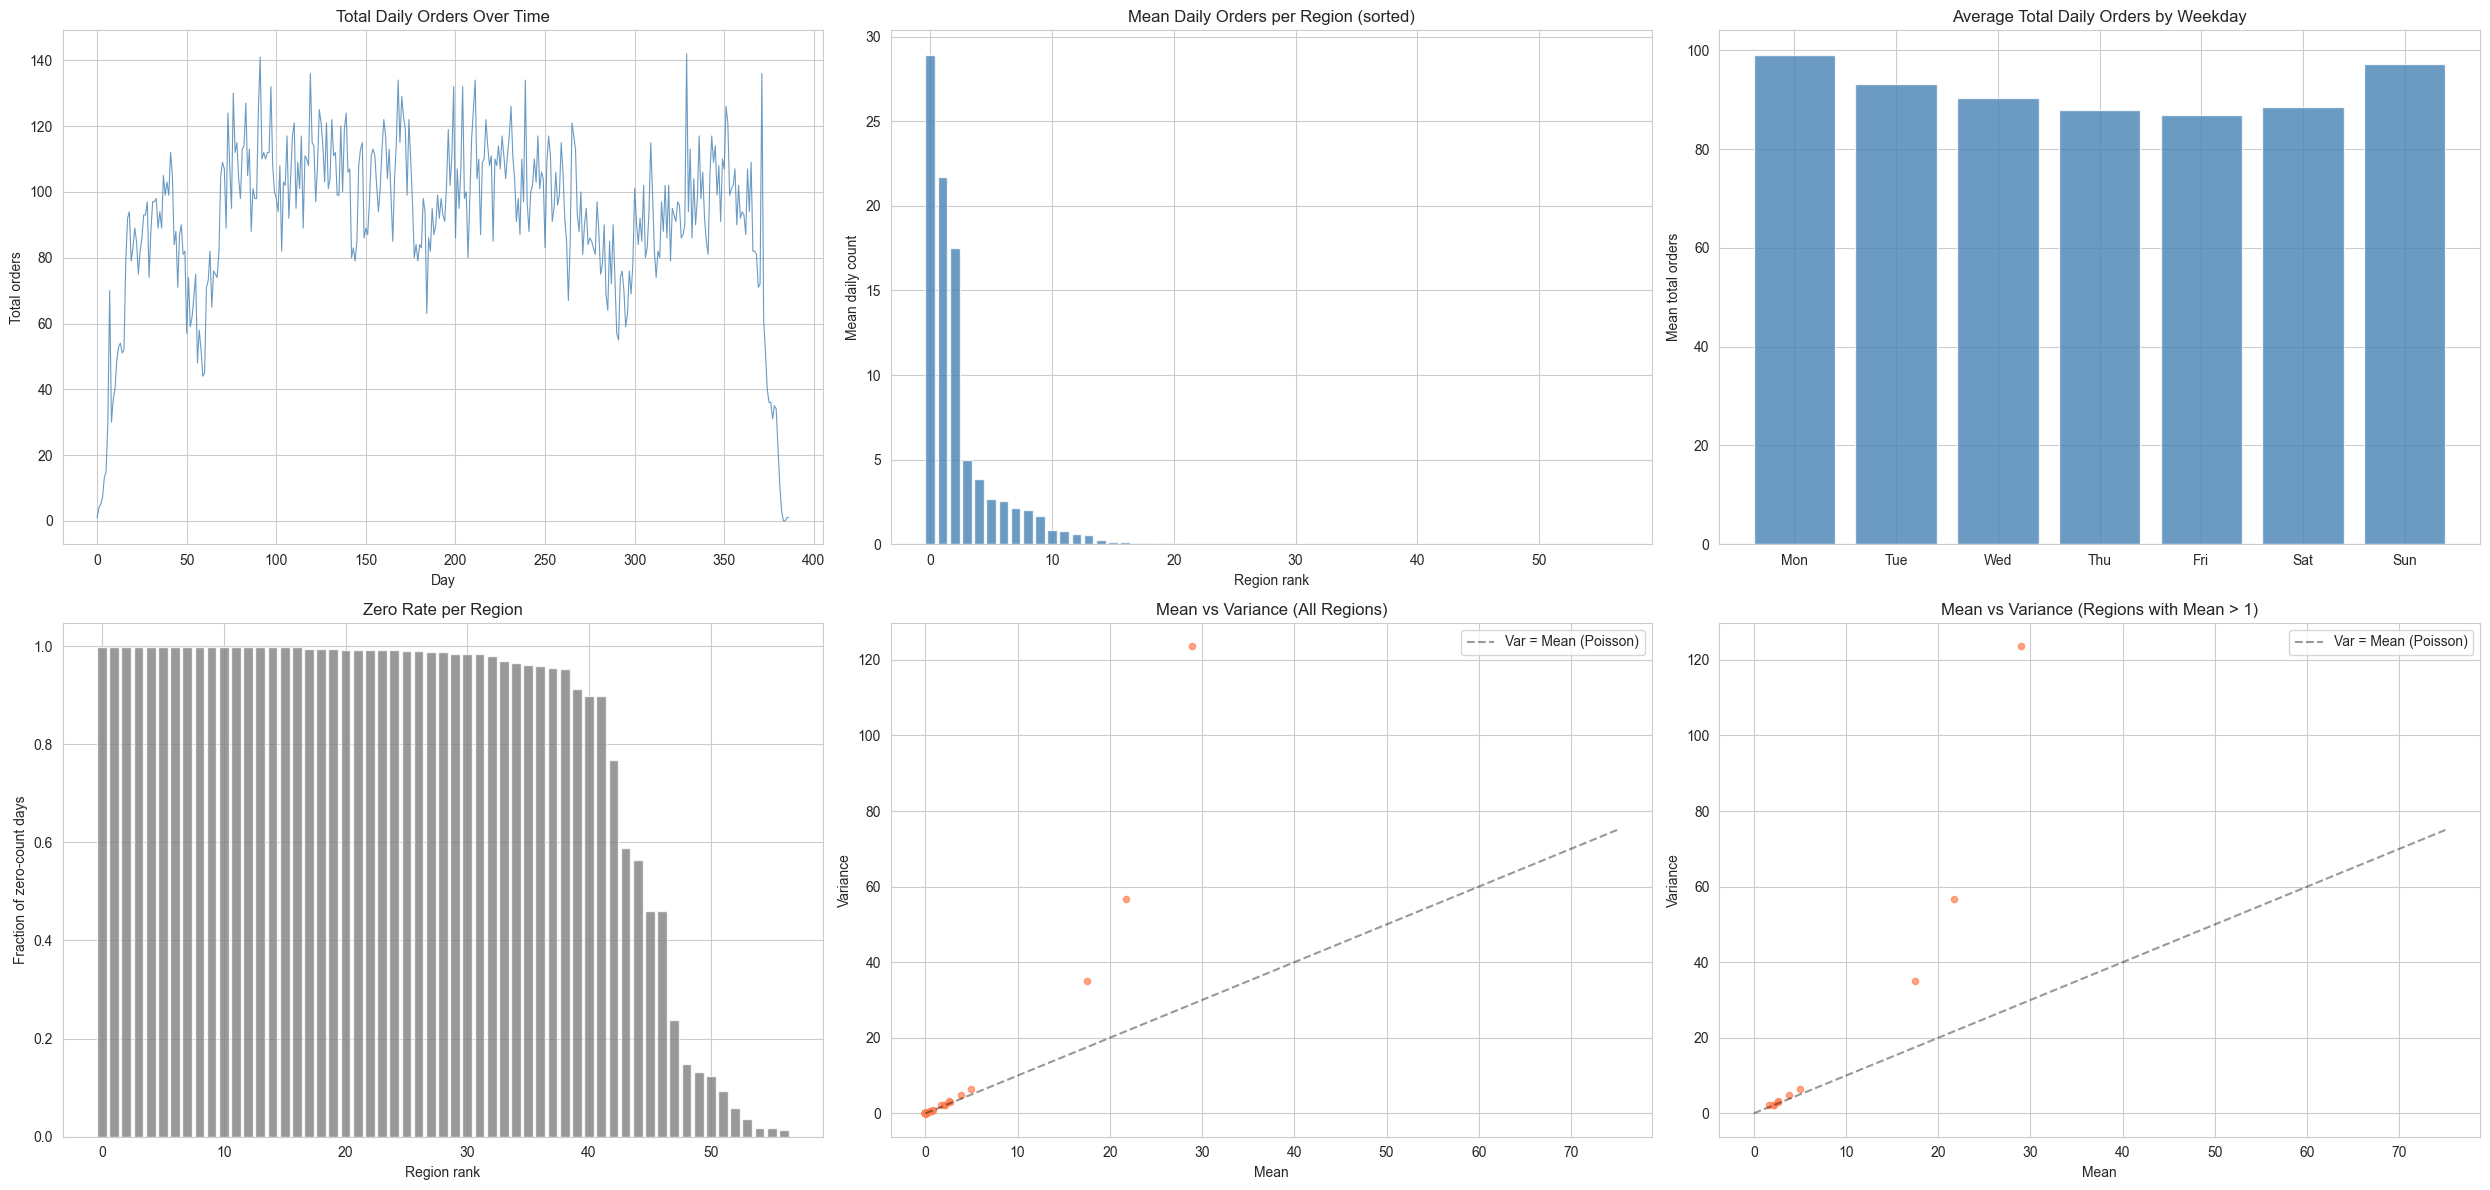

Regions with mean > 1:  10
Regions with mean > 10: 3
Overdispersion ratio (var/mean) median (all regions): 1.00000
Overdispersion ratio (var/mean) median (regions with mean > 0): 1.00000
Overdispersion ratio (var/mean) median (regions with mean > 0.25): 1.15126
Overdispersion ratio (var/mean) median (regions with mean > 0.5): 1.20237
Overdispersion ratio (var/mean) median (regions with mean > 0.75): 1.25721
Overdispersion ratio (var/mean) median (regions with mean > 1): 1.26413


In [34]:
# DAILY ORDERS

# Build region-level stats from orders_df (counts, means, vars)
all_region_ids = sorted(regions_df["regionid"].unique())
n_days = orders_df["day_id"].max() + 1
region_counts = orders_df.groupby(["day_id", "regionid"]).size().unstack(fill_value=0)
region_counts = region_counts.reindex(index=range(n_days), columns=all_region_ids, fill_value=0)
region_means = region_counts.mean(axis=0).values
region_vars = region_counts.var(axis=0).values
region_zeros = (region_counts == 0).mean(axis=0).values
n_regions_all = len(all_region_ids)

# Get weekday profile
n_days = orders_df["day_id"].max() + 1
weekdays = np.arange(n_days) % 7  # day_id=0 -> Jan 1 -> assign weekday
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily_totals = orders_df.groupby("day_id").size().reindex(range(n_days), fill_value=0).values
weekday_means = np.array([daily_totals[weekdays == d].mean() for d in range(7)])

# Plots
fig, axes = plt.subplots(2, 3, figsize=(25, 12))

axes[0, 0].plot(daily_totals, linewidth=0.8, color="steelblue", alpha=0.8)
axes[0, 0].set_title("Total Daily Orders Over Time")
axes[0, 0].set_xlabel("Day")
axes[0, 0].set_ylabel("Total orders")

axes[0, 1].bar(range(n_regions_all), np.sort(region_means)[::-1], color="steelblue", alpha=0.8)
axes[0, 1].set_title("Mean Daily Orders per Region (sorted)")
axes[0, 1].set_xlabel("Region rank")
axes[0, 1].set_ylabel("Mean daily count")

axes[0, 2].bar(weekday_names, weekday_means, color="steelblue", alpha=0.8)
axes[0, 2].set_title("Average Total Daily Orders by Weekday")
axes[0, 2].set_ylabel("Mean total orders")

axes[1, 0].bar(range(n_regions_all), np.sort(region_zeros)[::-1], color="grey", alpha=0.8)
axes[1, 0].set_title("Zero Rate per Region")
axes[1, 0].set_xlabel("Region rank")
axes[1, 0].set_ylabel("Fraction of zero-count days")

axes[1, 1].scatter(region_means, region_vars, s=20, alpha=0.7, color="coral")
max_val = 75
axes[1, 1].plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="Var = Mean (Poisson)")
axes[1, 1].set_title("Mean vs Variance (All Regions)")
axes[1, 1].set_xlabel("Mean")
axes[1, 1].set_ylabel("Variance")
axes[1, 1].legend()

mask = region_means > 1
axes[1, 2].scatter(region_means[mask], region_vars[mask], s=20, alpha=0.7, color="coral")
axes[1, 2].plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="Var = Mean (Poisson)")
axes[1, 2].set_title("Mean vs Variance (Regions with Mean > 1)")
axes[1, 2].set_xlabel("Mean")
axes[1, 2].set_ylabel("Variance")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Regions with mean > 1:  {mask.sum()}")
print(f"Regions with mean > 10: {(region_means > 10).sum()}")
ratio_all = region_vars / np.clip(region_means, 1e-12, None)

print(f"Overdispersion ratio (var/mean) median (all regions): {np.median(ratio_all):.5f}")
print(f"Overdispersion ratio (var/mean) median (regions with mean > 0): {np.median(region_vars[region_means > 0] / region_means[region_means > 0]):.5f}")
print(f"Overdispersion ratio (var/mean) median (regions with mean > 0.25): {np.median(region_vars[region_means > 0.25] / region_means[region_means > 0.25]):.5f}")
print(f"Overdispersion ratio (var/mean) median (regions with mean > 0.5): {np.median(region_vars[region_means > 0.5] / region_means[region_means > 0.5]):.5f}")
print(f"Overdispersion ratio (var/mean) median (regions with mean > 0.75): {np.median(region_vars[region_means > 0.75] / region_means[region_means > 0.75]):.5f}")
print(f"Overdispersion ratio (var/mean) median (regions with mean > 1): {np.median(region_vars[region_means > 1] / region_means[region_means > 1]):.5f}")

## 3. Preprocessing

We use the following preprocessing pipeline:

1. **Order-count panel $N_{r,t}$**: We aggregate orders into a $(T \times R)$ matrix of daily counts per region, where $T$ is the number of days and $R$ the number of regions.
2. **Calendar covariates**: We create weekday indicators (with Monday as reference) and monthly indicators (with January as reference).  Additionally, we add Fourier terms for smooth annual seasonality.

In [35]:
# HELPERS

def build_order_count_panel(orders_df: pd.DataFrame, regions_df: pd.DataFrame) -> tuple:
    """
    Builds a daily order-count matrix from raw order data.

    Args:
        orders_df (pd.DataFrame): Orders with columns 'day_id' and 'regionid'.
        regions_df (pd.DataFrame): Regions with column 'regionid' defining the region universe.

    Returns:
        counts_panel (np.ndarray): Daily order counts. Shape: (T, R). Dtype: int.
        all_region_ids (list): Sorted list of region IDs. Length: R.
        region_id_to_idx (dict): Mapping from region ID to column index.
    """
    all_region_ids = sorted(regions_df["regionid"].unique())
    R_all = len(all_region_ids)
    region_id_to_idx = {rid: i for i, rid in enumerate(all_region_ids)}

    T_data = orders_df["day_id"].max() + 1

    counts_panel = np.zeros((T_data, R_all), dtype=int)
    for _, row in orders_df.iterrows():
        t = row["day_id"]
        r_idx = region_id_to_idx.get(row["regionid"])
        if r_idx is not None:
            counts_panel[t, r_idx] += 1

    return counts_panel

def build_calendar_features(T: int, n_fourier: int = 0, period: int = 365) -> pd.DataFrame:
    """
    Builds a calendar feature matrix for T consecutive days starting from day 0 (= Jan 1).

    Args:
        T (int): Number of days.
        n_fourier (int): Number of Fourier harmonic pairs for annual seasonality.
        period (int): Period for Fourier terms in days.

    Returns:
        features (pd.DataFrame): Calendar feature matrix. Shape: (T, n_features).
    """
    days = np.arange(T)

    # Weekday: day_id=0 is Jan 1 -> we just need day_id % 7 for consistent encoding
    weekday = days % 7  # 0=Mon, 1=Tue, ... 6=Sun (reference)

    # Month: derive from day_id assuming day_id=0 is Jan 1 of a non-leap year
    day_of_year = days % 365
    month_days = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    month_boundaries = np.cumsum(month_days)
    month = np.searchsorted(month_boundaries, day_of_year, side="right")  # 0=Jan, 11=Dec (reference)

    features = {}

    # Weekday dummies (Mon=0 through Sat=5; Sun=6 is reference)
    for d in range(6):
        features[f"wd_{d}"] = (weekday == d).astype(float)

    # Month dummies (Jan=0 through Nov=10; Dec=11 is reference)
    for m in range(11):
        features[f"mo_{m}"] = (month == m).astype(float)

    # Fourier terms
    for h in range(1, n_fourier + 1):
        features[f"sin_{h}"] = np.sin(2 * np.pi * h * days / period)
        features[f"cos_{h}"] = np.cos(2 * np.pi * h * days / period)

    return pd.DataFrame(features, index=days)

In [36]:
# ORDER-COUNT PANEL

# Build the order-count panel
all_region_ids = sorted(regions_df["regionid"].unique())
R_all = len(all_region_ids)
T_data = orders_df["day_id"].max() + 1
counts_panel = build_order_count_panel(orders_df, regions_df)

print(f"Count panel shape: {counts_panel.shape}  (T={T_data}, R={R_all})")
print(f"Total orders in panel: {counts_panel.sum():,}")
print(f"Overall mean daily count per region: {counts_panel.mean():.2f}")
print(f"Overall max daily count per region:  {counts_panel.max()}")
print(f"Fraction of zeros: {(counts_panel == 0).mean():.2%}")

Count panel shape: (387, 57)  (T=387, R=57)
Total orders in panel: 35,562
Overall mean daily count per region: 1.61
Overall max daily count per region:  56
Fraction of zeros: 78.92%


In [37]:
# CALENDAR COVARIATES

# Build calendar features
calendar_df = build_calendar_features(T_data, n_fourier=N_FOURIER_HARMONICS, period=FOURIER_PERIOD)

# Print results
print(f"Calendar features shape: {calendar_df.shape}")
print(f"Columns: {calendar_df.columns.tolist()}")
calendar_df.head(10)

Calendar features shape: (387, 21)
Columns: ['wd_0', 'wd_1', 'wd_2', 'wd_3', 'wd_4', 'wd_5', 'mo_0', 'mo_1', 'mo_2', 'mo_3', 'mo_4', 'mo_5', 'mo_6', 'mo_7', 'mo_8', 'mo_9', 'mo_10', 'sin_1', 'cos_1', 'sin_2', 'cos_2']


,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,mo_0,mo_1,mo_2,mo_3,...,mo_5,mo_6,mo_7,mo_8,mo_9,mo_10,sin_1,cos_1,sin_2,cos_2
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,0.034422,0.999407
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.034422,0.999407,0.068802,0.997630
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.051620,0.998667,0.103102,0.994671
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.068802,0.997630,0.137279,0.990532
5,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.085965,0.996298,0.171293,0.985220
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.103102,0.994671,0.205104,0.978740
7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.120208,0.992749,0.238673,0.971100
8,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.137279,0.990532,0.271958,0.962309
9,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.154309,0.988023,0.304921,0.952378


## 4. Fit Per-Region Seasonality via NB-GLM

For each region $r$, we model daily order counts $N_{r,t}$ with a Negative Binomial GLM (log link) to capture calendar-driven seasonality and region-specific overdispersion:

$$
N_{r,t}\mid S_t \sim \mathrm{NB2}(\mu_{r,t}, \alpha_r),
\qquad
\log \mu_{r,t} = b_r + S_t^\top \beta_r .
$$

where $S_t$ contains seasonal regressors (weekday, month, and Fourier terms) and $\alpha_r>0$ is a region-specific dispersion parameter. Larger $\alpha_r$ implies stronger overdispersion and $\alpha_r = 0$ indicates the Poisson case. Note that some parametrizations use a size/shape parameter $\kappa_r$ and map it via $\alpha_r = \frac{1}{\kappa_r}$. $\mathrm{NB2}$ is the Negative Binomial model with quadratic mean-variance relationship:

$$
\mathrm{Var}(N_{r,t}\mid X_t) = \mu_{r,t} + \alpha_r \mu_{r,t}^2,
\qquad \alpha_r>0,
$$


### Iterative $\alpha_r$ Estimation Approach

Because $\alpha_r$ is initially unknown, we use an alternating estimation scheme:

1. **Initialize with a Poisson GLM (log link)**:
    Get an initial estimation for $\mu_{r,t}$ using the dispersion-free Poisson model: 
    $$N_{r,t}\sim \text{Poisson}(\mu_{r,t}), \qquad \log\mu_{r,t} = x_t^\top \beta_r^{(0)}.$$
    This yields initially fitted means $\hat\mu_{r,t}^{(0)}$ (without overdispersion).

2) **Moment-based NB2 dispersion estimate (Lawless-style):**  
    Given fitted means $\hat\mu_{r,t}$, estimate NB2 dispersion using the Lawless (1987) moment-based dispersion estimator:
    $$\hat\alpha_r \;=\; \frac{\sum_{t=1}^T\left[(N_{r,t}-\hat\mu_{r,t})^2-\hat\mu_{r,t}\right]}{\sum_{t=1}^T \hat\mu_{r,t}^2}.$$
    Once estimated, clamp $\hat\alpha_r$ to a safe range to avoid degenerate (negative/near-zero) dispersion estimates and improve numerical stability:
    $$\hat\alpha_r \leftarrow \min\bigl(10,\max(10^{-4},\hat\alpha_r)\bigr).$$

3) **Fit NB-GLM given $\hat\alpha_r$:**  
    Fit the NB2 GLM with $\alpha_r$ fixed:
    $$N_{r,t}\sim \mathrm{NB2}(\mu_{r,t},\alpha_r=\hat\alpha_r), \qquad \log\mu_{r,t} = x_t^\top \beta_r.$$
    This yield updated fitted means $\hat\mu_{r,t}^{(1)}$.

4) **Iterate until convergence:**  
Repeat steps 2–3 for $k=1,\dots,K$ (e.g., $K=5$) to update $\hat\alpha_r^{(k)}$ and $\hat\mu_{r,t}^{(k)}$ until dispersion stabilizes:
$$\frac{\left|\hat\alpha_r^{(k)}-\hat\alpha_r^{(k-1)}\right|}{\max(\hat\alpha_r^{(k-1)},10^{-6})} < 0.01.$$


For each region $r$ this iterative estimation approach yields:
- seasonal coefficients $\hat\beta_r$,
- dispersion $\hat\alpha_r$,
- seasonal fitted values (conditional means) $\widehat{\mu}_{r,t} = \exp(x_t^\top \hat\beta_r),$ which we stack into a matrix $\widehat{\mu}\in\mathbb{R}^{T\times R}$ for all regions.


---

**Note:** This step serves as a *diagnostic and validation* checkpoint. Its fitted values do *not* feed into the PCA residual panel (Step 5 uses OLS on log-transformed counts instead). The seasonal NB fit is used for visual inspection and to confirm that calendar-driven seasonality can be captured in count space before proceeding. The helper `_estimate_nb2_alpha` and the iterative NB fitting logic introduced here are reused in Step 8 for the full model (`fit_nb_full`).

In [9]:
def _estimate_nb2_alpha(counts: np.ndarray, mu: np.ndarray) -> float:
    """
    Lawless (1987) moment estimator for the NB2 dispersion parameter alpha.

    For NB2: Var(Y) = mu + alpha * mu^2.

    Args:
        counts (np.ndarray): Observed counts. Shape: (T,).
        mu (np.ndarray): Fitted conditional mean. Shape: (T,).

    Returns:
        alpha (float): Estimated dispersion (clamped to [1e-4, 10]).
    """
    resid_sq = (counts - mu) ** 2
    mu2_sum = np.sum(mu ** 2)
    if mu2_sum < 1e-10:
        return 1.0
    alpha = np.sum(resid_sq - mu) / mu2_sum
    return float(np.clip(alpha, 1e-4, 10.0))

def fit_nb_seasonality(counts: np.ndarray, X: np.ndarray,
                       n_iter: int = 5) -> dict:
    """
    Fits a Negative Binomial GLM (log-link, NB2) for a single region's daily
    counts using an iterative procedure that alternates between fitting the
    regression coefficients and re-estimating alpha from the residuals.

    Args:
        counts (np.ndarray): Daily order counts. Shape: (T,).
        X (np.ndarray): Design matrix (with constant). Shape: (T, n_features).
        n_iter (int): Maximum number of alpha re-estimation iterations.

    Returns:
        result (dict): Dictionary with keys 'params', 'alpha', 'fitted_values', 'converged'.
    """
    try:
        pois = sm.GLM(counts, X, family=sm.families.Poisson())
        pois_fit = pois.fit(maxiter=100, disp=False)
        mu = pois_fit.fittedvalues
        alpha = _estimate_nb2_alpha(counts, mu)

        fit = pois_fit
        for _ in range(n_iter):
            model = sm.GLM(counts, X,
                           family=sm.families.NegativeBinomial(alpha=alpha))
            fit = model.fit(maxiter=100, disp=False)
            mu = fit.fittedvalues
            alpha_new = _estimate_nb2_alpha(counts, mu)
            if abs(alpha_new - alpha) / max(alpha, 1e-6) < 0.01:
                break
            alpha = alpha_new

        return {
            "params": fit.params,
            "alpha": alpha,
            "fitted_values": fit.fittedvalues,
            "converged": fit.converged,
        }
    except Exception:
        model = sm.GLM(counts, X, family=sm.families.Poisson())
        fit = model.fit(maxiter=200, disp=False)
        return {
            "params": fit.params,
            "alpha": 1e-4,
            "fitted_values": fit.fittedvalues,
            "converged": fit.converged,
        }

In [10]:
# FIT SEASONAL MODEL

# Add constant to the model
X_seasonal = sm.add_constant(calendar_df.values)

# Fit model for all regions
seasonal_fits = []
for r in range(R_all):
    result = fit_nb_seasonality(counts_panel[:, r], X_seasonal)
    seasonal_fits.append(result)

# Get number of converged regions
n_converged = sum(1 for f in seasonal_fits if f["converged"])

# Collect seasonal fitted parameters
seasonal_fitted = np.column_stack([f["fitted_values"] for f in seasonal_fits])

# Print results
print(f"Seasonal NB-GLM fitted for {R_all} regions ({n_converged} converged)")
print(f"Seasonal fitted values shape: {seasonal_fitted.shape}")

Seasonal NB-GLM fitted for 57 regions (46 converged)
Seasonal fitted values shape: (387, 57)


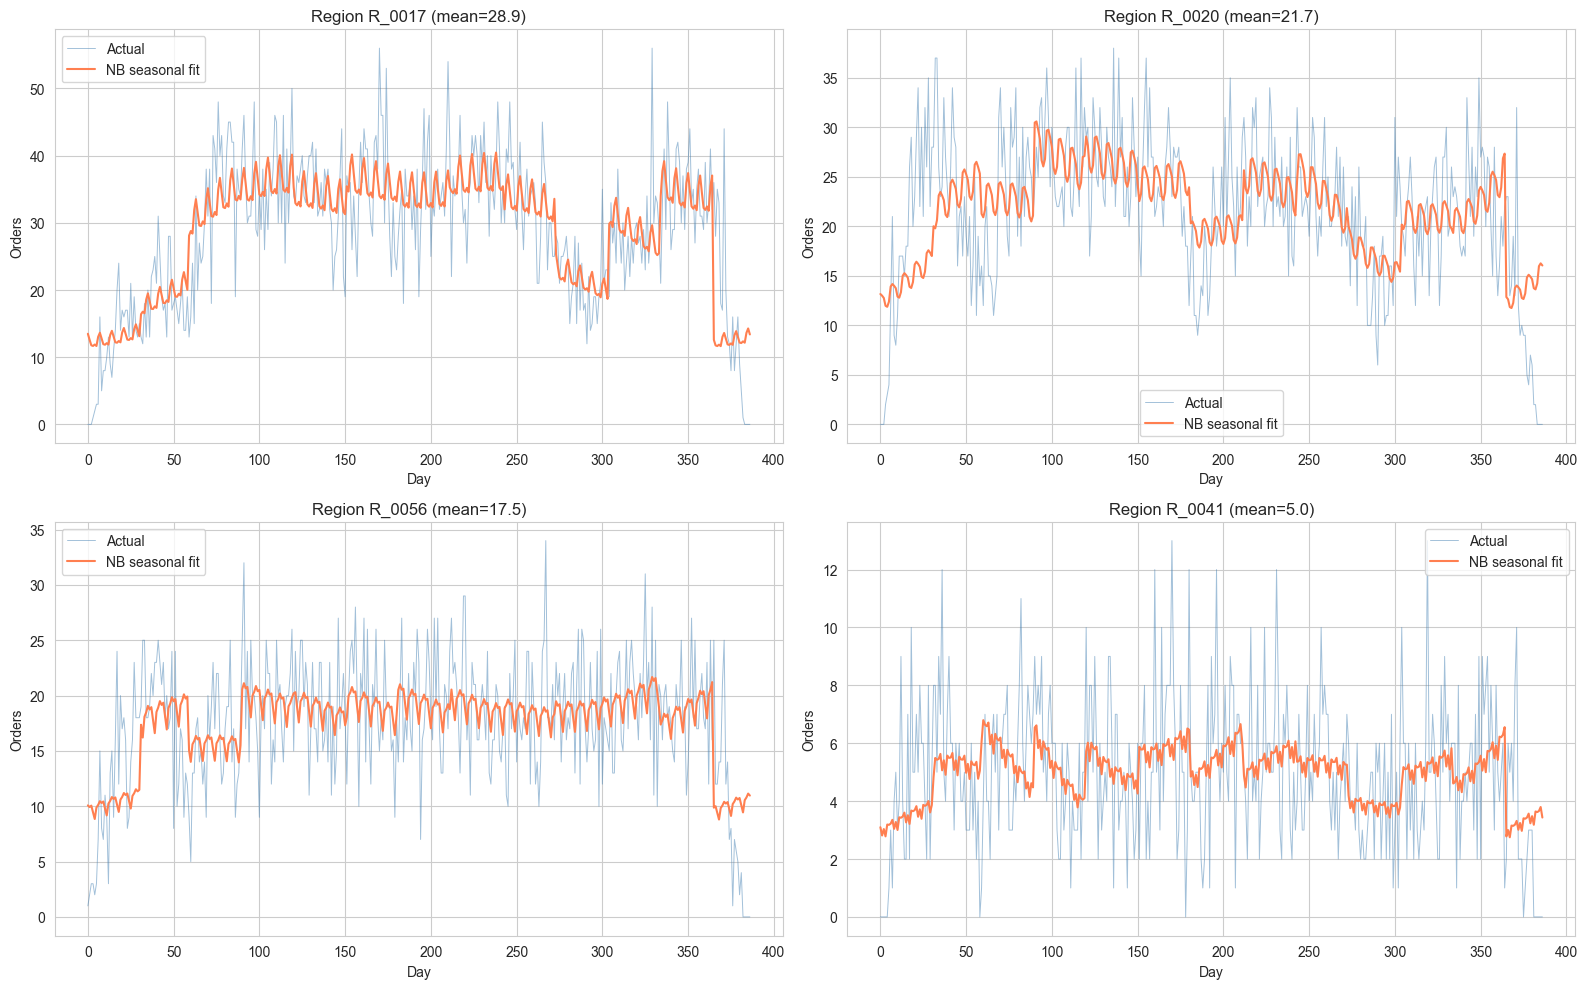

In [11]:
# VISUALIZE

# Sort regions by mean daily order count
top_regions = np.argsort(region_means)[::-1][:4]

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, r in enumerate(top_regions):
    ax = axes[i // 2, i % 2]
    ax.plot(counts_panel[:, r], alpha=0.5, linewidth=0.7, label="Actual", color="steelblue")
    ax.plot(seasonal_fitted[:, r], linewidth=1.5, label="NB seasonal fit", color="coral")
    ax.set_title(f"Region {all_region_ids[r]} (mean={region_means[r]:.1f})")
    ax.set_xlabel("Day")
    ax.set_ylabel("Orders")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Shared-Factor Extraction via PCA

To capture cross-region co-movement in demand, we estimate a low-dimensional latent factor process from a transformed and de-seasonalized panel. Because raw counts are nonnegative, zero-inflated, and heteroskedastic, we work on a variance-stabilized scale for factor extraction only (the final generator remains count-based).

### 5.1 Build PCA Panel (standardized and de-seasonalized)

For each region $r$ and day $t$, we transform the associated values to log-space:
$$
y_{r,t}=\log(N_{r,t}+c), \qquad c\in\{0.5,1\}.
$$
We then remove deterministic calendar effects by regressing $y_{r,t}$ on weekday/month indicators as well as on Fourier terms and taking residuals:
$$
y_{r,t} = b_r + S_t^\top \beta_r + \varepsilon_{r,t},
\qquad
\tilde y_{r,t} := \hat\varepsilon_{r,t}.
$$
To obtain the final PCA panel, we stack residuals into the matrix $\tilde Y\in\mathbb{R}^{T\times R}$ with entries $\tilde Y_{t,r}=\tilde y_{r,t}$ and standardize each column to prevent high-variance regions from dominating:
$$
\tilde Y_{t,r}^{\mathrm{std}} = \tilde y^{\mathrm{std}}_{r,t}=\frac{\tilde y_{r,t}-\bar{\tilde y}_r}{s_r}.
$$

### 5.3 Extract Common Factors and Loadings via PCA
Apply PCA to $\tilde Y^{\mathrm{std}}$ and retain $K$ components via scree plot and explained variance. This yields a factor–loading decomposition:
$$
\tilde y_{r,t}\approx u_t^\top \lambda_r + e_{r,t},
$$
where $u_t\in\mathbb{R}^K$ are the shared latent factors and $\lambda_r\in\mathbb{R}^K$ are region-specific loadings. Since PCA factors are identifiable up to sign/rotation, we keep the estimated $\hat u_t$ consistently for downstream mapping into the count-likelihood model.

In [12]:
# PCA PANEL CREATION

# Log transform counts
Y_log = np.log(counts_panel + VS_CONSTANT)

# Inizialize arrays
Y_resid = np.zeros_like(Y_log)
ols_seasonal_params = []

# Run OLS to remove seasonal effects and get residuals
for r in range(R_all):
    ols_model = sm.OLS(Y_log[:, r], X_seasonal)
    ols_fit = ols_model.fit()
    Y_resid[:, r] = ols_fit.resid
    ols_seasonal_params.append(ols_fit.params)

# Standardize columns 
resid_means = Y_resid.mean(axis=0)
resid_stds = Y_resid.std(axis=0)
resid_stds[resid_stds < 1e-10] = 1.0  # avoid division by zero for inactive regions
Y_std = (Y_resid - resid_means) / resid_stds

# Print results
print(f"Standardized residual panel: mean≈{Y_std.mean():.6f}, std≈{Y_std.std():.4f}")


Standardized residual panel: mean≈-0.000000, std≈1.0000


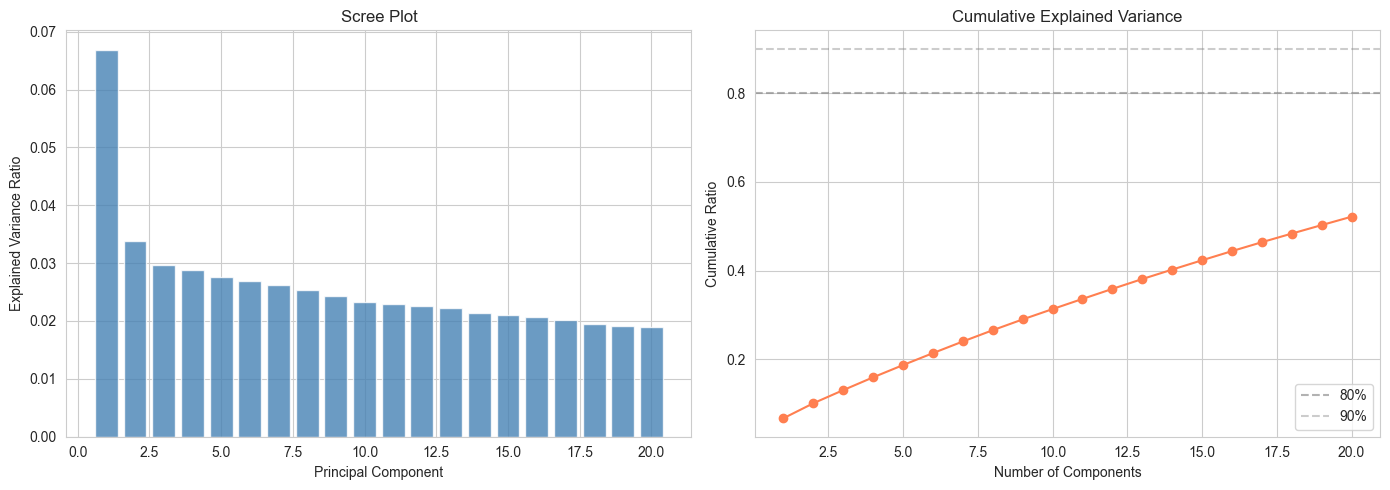

In [13]:
# PCA FACTOR EXTRACTION

# Run PCA
pca_full = PCA().fit(Y_std)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)     

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(20, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show], color="steelblue", alpha=0.8)
axes[0].set_title("Scree Plot")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, n_show + 1), cumulative[:n_show], "o-", color="coral")
axes[1].axhline(0.8, ls="--", color="grey", alpha=0.6, label="80%")
axes[1].axhline(0.9, ls="--", color="grey", alpha=0.4, label="90%")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Ratio")
axes[1].legend()

plt.tight_layout()
plt.show()

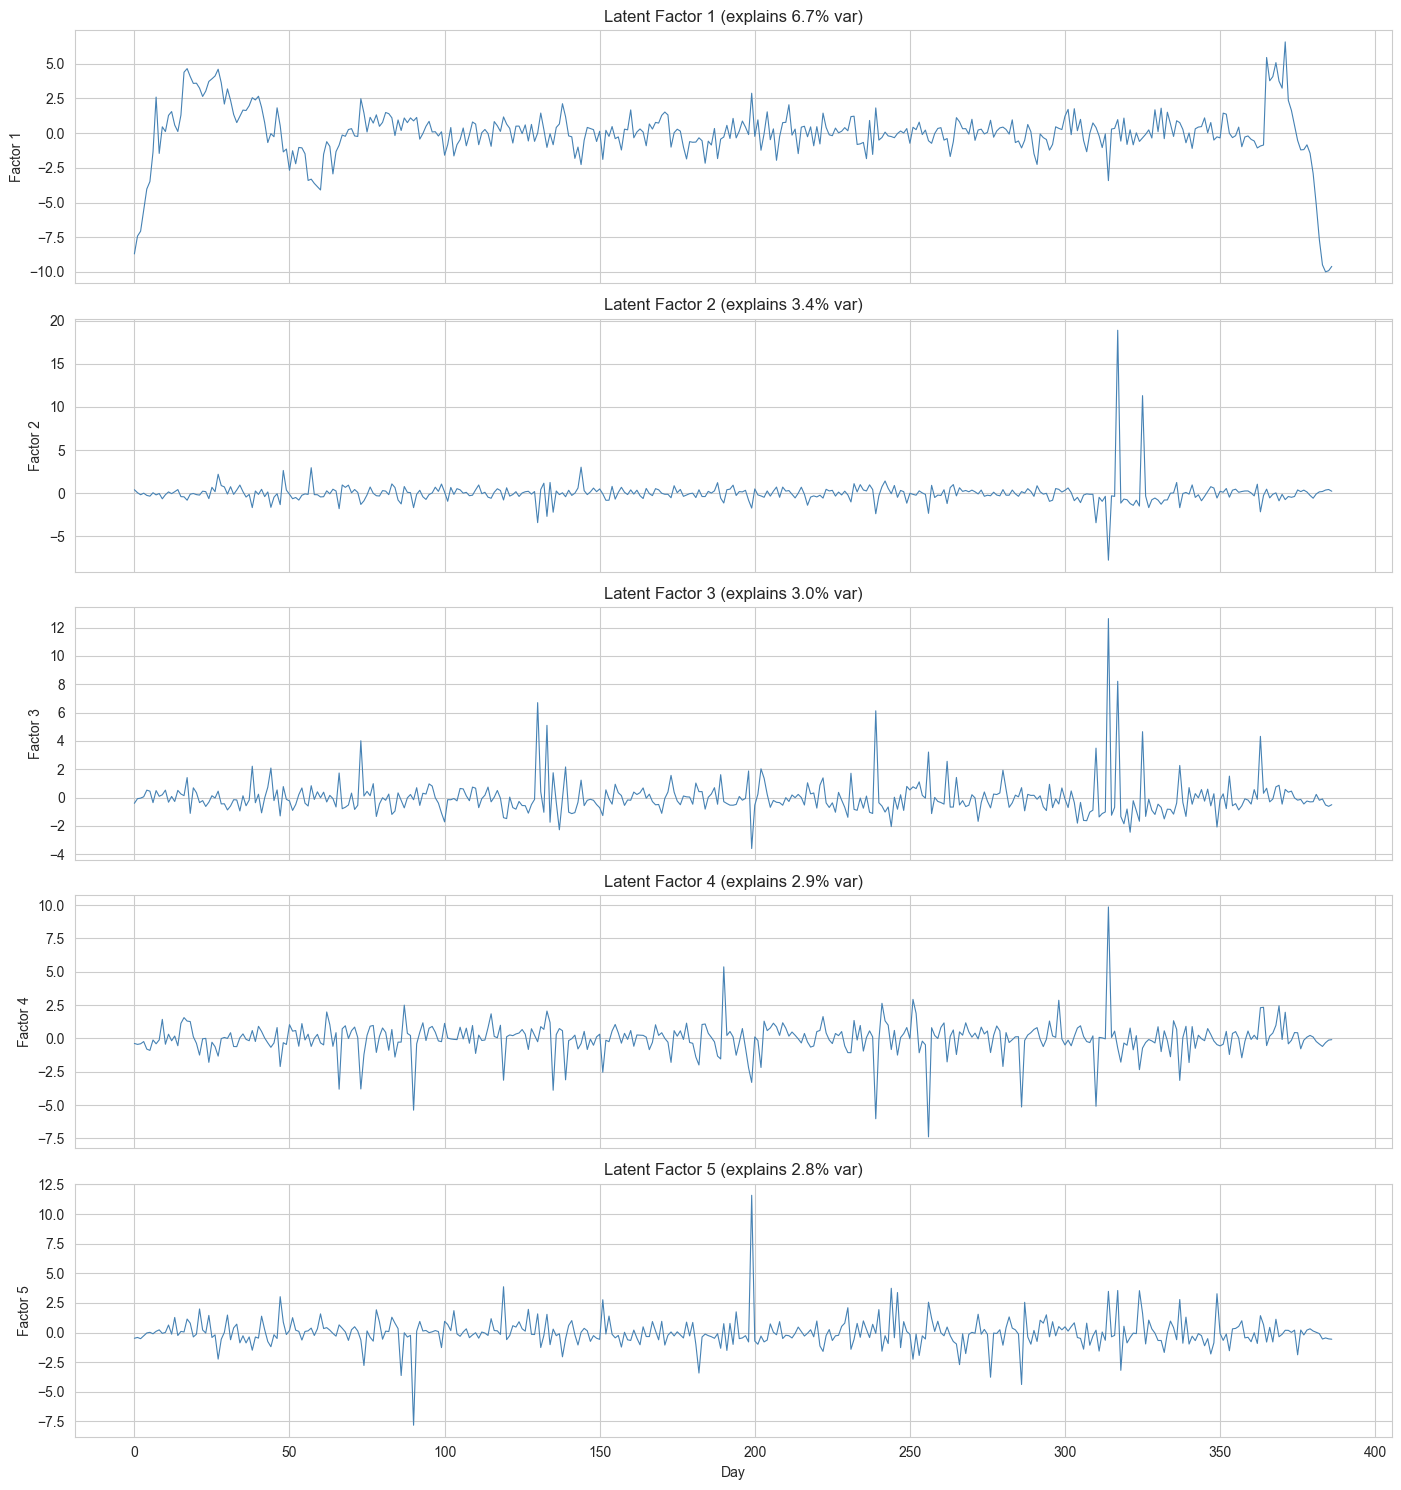

Number of factors extracted: 5
Variance explained by first 5 factors: 0.187
Factor scores shape:  (387, 5)  (T x K)
Region loadings shape: (57, 5)  (R x K)


In [14]:
# EXTRACT FACTORS AND VISUALIZE

# Extract K factors and compute factors and loadings
pca_model = PCA(n_components=N_FACTORS)
U_hat = pca_model.fit_transform(Y_std)    
B_hat = pca_model.components_.T     

# Plots
fig, axes = plt.subplots(N_FACTORS, 1, figsize=(14, 3 * N_FACTORS), sharex=True)
if N_FACTORS == 1:
    axes = [axes]
for k in range(N_FACTORS):
    axes[k].plot(U_hat[:, k], linewidth=0.8, color="steelblue")
    axes[k].set_ylabel(f"Factor {k+1}")
    axes[k].set_title(f"Latent Factor {k+1} (explains {explained[k]*100:.1f}% var)")
axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()

# Print results
print(f"Number of factors extracted: {N_FACTORS}")
print(f"Variance explained by first {N_FACTORS} factors: {cumulative[N_FACTORS - 1]:.3f}")
print(f"Factor scores shape:  {U_hat.shape}  (T x K)")
print(f"Region loadings shape: {B_hat.shape}  (R x K)")

## 6. Model Factor Dynamics via VAR

To generate time-consistent shared factor trajectories, we model the temporal dependence in the estimated factor series $\{\hat u_t\}_{t=1}^T$ with a vector autoregression VAR($p$). This preserves autocorrelation and cross-factor interactions while keeping the latent process low-dimensional. Specifically, we fit a VAR($p$) in the following form:
$$
\hat u_t = \sum_{i=1}^{p} A_i\,\hat u_{t-i} + \eta_t,
\qquad
\eta_t \sim \mathcal N(0,\Sigma_\eta),
$$
where $A_i\in\mathbb{R}^{K\times K}$ capture persistence and lead–lag structure across factors and $\Sigma_\eta$ is the innovation covariance. We select $p$ using AIC/BIC as information criterion and verify stability by checking if the eigenvalues of the companion matrix are strictly within the unit circle.

At generation time, we can use the VAR($p$) mode to simulate a new factor series $\{\hat u_t\}_{t=1}^T$ forward recursively:

$$
u_t = \sum_{i=1}^{p} A_i\,u_{t-i} + \eta_t,
\qquad
\eta_t \overset{iid}{\sim}\mathcal N(0,\Sigma_\eta).
$$

At generation time, we initialize the state $u_{1:p}$ either bootstrapping $p$ consecutive observations from the empirical factor series $\{\hat u_t\}_{t=1}^T$ or sampling from the stationary distribution implied by the fitted (and stable) VAR. We can then use the VAR model to simulate a new factor series recursively by drawing fresh innovations $\eta_t \overset{iid}{\sim} \mathcal N(0,\Sigma_\eta)$ at each time step $t$ and setting
$$
u_t = \sum_{i=1}^{p} A_i\,u_{t-i} + \eta_t.
$$

The resulting $u_t$ sequences serve as shared shocks that drive co-movement across regions in the subsequent NB mean model. 

In [15]:
# FIT VAR MODEL

# Fit the VAR model
var_model = VARModel(U_hat)
var_fit = var_model.fit(maxlags=VAR_ORDER)

# Print results
A_var = var_fit.coefs[0]    
Sigma_eta = var_fit.sigma_u 
print(f"VAR({VAR_ORDER}) fitted.")
print(f"  A matrix (lag 1):")
print(f"  {np.array2string(A_var, precision=4, suppress_small=True)}")
print(f"  Innovation covariance diagonal: {np.diag(Sigma_eta).round(4)}")

VAR(1) fitted.
  A matrix (lag 1):
  [[ 0.7997 -0.0688  0.056   0.1064  0.0141]
 [-0.0112 -0.0538 -0.0188 -0.0533  0.1221]
 [-0.0003 -0.0075 -0.1102  0.0369 -0.0224]
 [ 0.0187 -0.0922  0.0506  0.0177  0.0011]
 [ 0.0107 -0.061  -0.0539 -0.0437 -0.0951]]
  Innovation covariance diagonal: [1.3233 1.9273 1.6959 1.6532 1.573 ]


In [16]:
# STATIONARITY CHECK

# Check stationarity by investigating if all eigenvalues of A have modulus < 1
eigenvalues = np.linalg.eigvals(A_var)

# Print results
print(f"Eigenvalues of A: {eigenvalues}")
print(f"Max eigenvalue modulus: {np.max(np.abs(eigenvalues)):.4f}")
if np.all(np.abs(eigenvalues) < 1):
    print("VAR is stationary.")
else:
    print("WARNING: VAR is non-stationary — consider differencing or reducing lag order.")

Eigenvalues of A: [ 0.80352299+0.j          0.07696471+0.j         -0.09516191+0.08949195j
 -0.09516191-0.08949195j -0.13181156+0.j        ]
Max eigenvalue modulus: 0.8035
VAR is stationary.


## 7. Fit Full Per-Region Count Model (Seasonality + Shared Factors) via NB-GLM

For each region $r$, we fit a Negative Binomial GLM with log link that combines both the deterministic calendar-driven seasonality and the shared latent demand factors obtained from PCA/VAR. The likelihood and dispersion handling follow the same NB2 setup and estimation as described in Step 4. Specifically, we model
$$
N_{r,t}\mid S_t,u_t \sim \mathrm{NB2}(\mu_{r,t}, \alpha_r),
\qquad
\log \mu_{r,t} = b_r + S_t^\top \beta_r + u_t^\top \gamma_r.
$$
where $b_r$ is the log baseline, $\beta_r$ are region-specific seasonality coefficients (weekday, month, Fourier terms), $\gamma_r\in\mathbb{R}^K$ are region-specific factor coefficients, and $\alpha_r>0$ is the region-specific dispersion (NB2).

We define the feature matrix as $X_r=[\mathbf{1},\,S,\,U]$ and fit the model following the approach outline in Step 4:
1. Initialize with a Poisson-GLM to obtain $\hat\mu_{r,t}^{(0)}$.
2. Estimate $\hat\alpha_r$ from residuals using the Lawless-style moment estimator.
3. Refit NB-GLM with fixed $\alpha_r=\hat\alpha_r$
4. Iterate steps 2–3 until $\hat\alpha_r$ converges.

After fitting, this step returns for each region $r$ the full coefficient vector $\hat\theta_r = (\hat b_r, \hat\beta_r, \hat\gamma_r)$, the dispersion estimate $\hat\alpha_r$, and the fitted conditional means $\widehat{\mu}_{r,t}=\exp(X_{r,t}^\top \hat\theta_r)$. Moreover, stacking across regions yields parameter collections $\{\hat\theta_r,\hat\alpha_r\}_{r=1}^R$ used in simulation to compute $\mu_{r,t}$ and draw counts from $\mathrm{NB2}(\mu_{r,t},\hat\alpha_r)$.

In [17]:
# HELPERS

def fit_nb_full(counts: np.ndarray, X: np.ndarray,
                n_iter: int = 5) -> dict:
    """
    Fits a Negative Binomial GLM (log-link, NB2) with the full design matrix
    using an iterative procedure that alternates between fitting the regression
    coefficients and re-estimating alpha from the residuals (Lawless 1987).

    Args:
        counts (np.ndarray): Daily order counts. Shape: (T,).
        X (np.ndarray): Full design matrix (with constant). Shape: (T, n_features).
        n_iter (int): Maximum number of alpha re-estimation iterations.

    Returns:
        result (dict): Dictionary with keys 'params', 'alpha', 'fitted_values',
                       'log_mu', 'converged'.
    """
    try:
        pois = sm.GLM(counts, X, family=sm.families.Poisson())
        pois_fit = pois.fit(maxiter=100, disp=False)
        mu = pois_fit.fittedvalues
        alpha = _estimate_nb2_alpha(counts, mu)

        fit = pois_fit
        for _ in range(n_iter):
            model = sm.GLM(counts, X,
                           family=sm.families.NegativeBinomial(alpha=alpha))
            fit = model.fit(maxiter=100, disp=False)
            mu = fit.fittedvalues
            alpha_new = _estimate_nb2_alpha(counts, mu)
            if abs(alpha_new - alpha) / max(alpha, 1e-6) < 0.01:
                break
            alpha = alpha_new

        return {
            "params": fit.params,
            "alpha": alpha,
            "fitted_values": fit.fittedvalues,
            "log_mu": np.log(np.maximum(fit.fittedvalues, 1e-10)),
            "converged": fit.converged,
        }
    except Exception:
        model = sm.GLM(counts, X, family=sm.families.Poisson())
        fit = model.fit(maxiter=300, disp=False)
        return {
            "params": fit.params,
            "alpha": 1e-4,
            "fitted_values": fit.fittedvalues,
            "log_mu": np.log(np.maximum(fit.fittedvalues, 1e-10)),
            "converged": fit.converged,
        }

In [18]:
# FIT NB2 MODEL

# Build the full design matrix
X_full = np.column_stack([np.ones(T_data), calendar_df.values, U_hat])  # (T, 1 + n_cal + K)
n_cal_features = calendar_df.shape[1]

# Fit model for all regions
full_fits = []
for r in range(R_all):
    result = fit_nb_full(counts_panel[:, r], X_full)
    full_fits.append(result)

# Get the number of converged regions
n_converged = sum(1 for f in full_fits if f["converged"])

# Collect fitted parameters (params = full coefficient vector, beta = intercept)
all_params = np.array([f["params"] for f in full_fits])     # (R, n_features)
all_beta = all_params[:, 0]                                 # (R,) — intercept per region
all_alpha = np.array([f["alpha"] for f in full_fits])       # (R,)
all_kappa = 1.0 / all_alpha                                 # (R,) — for NB size param in simulation

# Print results
print(f"Full NB-GLM fitted for {R_all} regions ({n_converged} converged)")
print(f"Dispersion (alpha) — median: {np.median(all_alpha):.4f}, range: [{all_alpha.min():.4f}, {all_alpha.max():.4f}]")

Full NB-GLM fitted for 57 regions (55 converged)
Dispersion (alpha) — median: 0.0001, range: [0.0001, 0.0051]


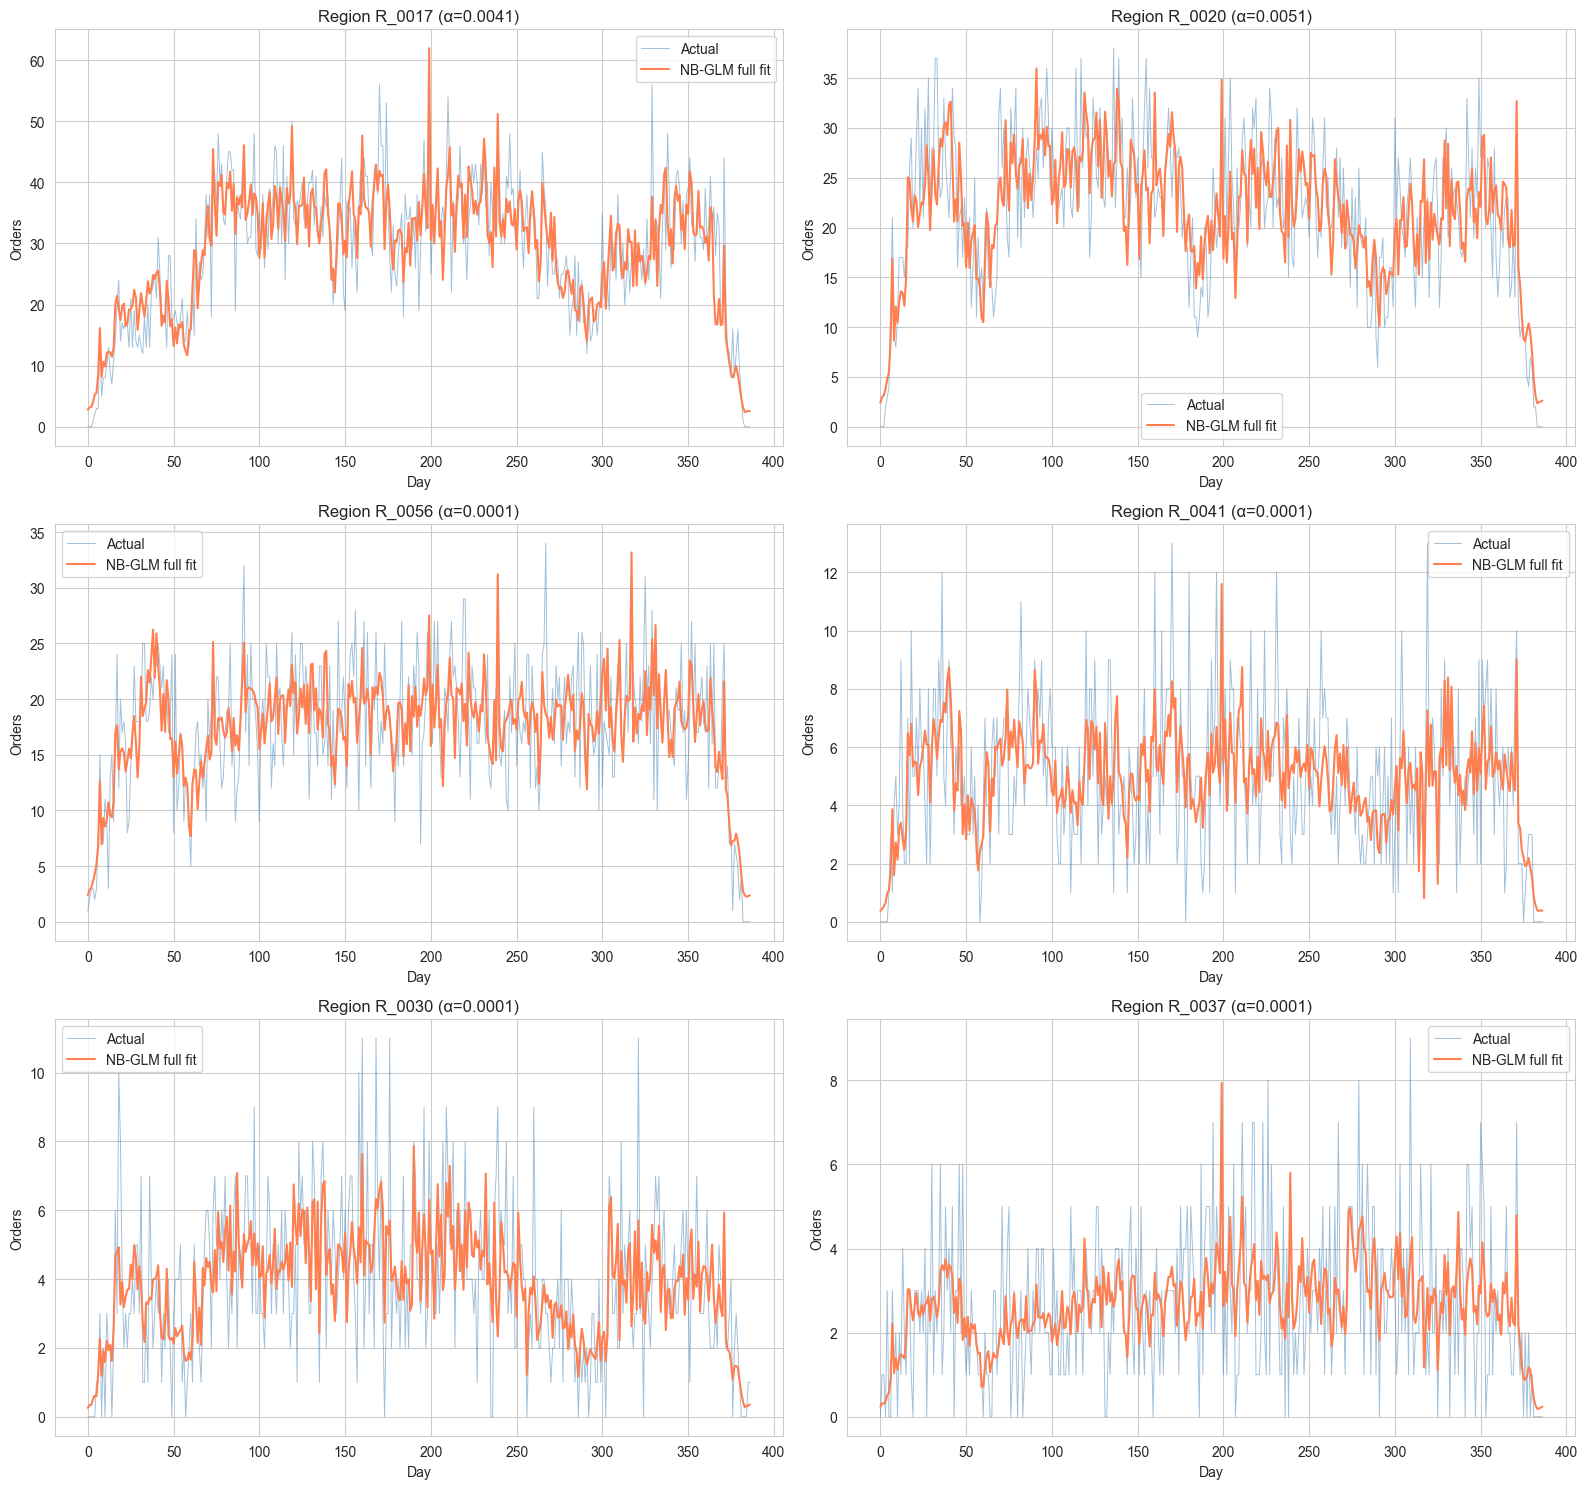

In [19]:
# VISZUALIZE

# Get the full fitted values
full_fitted = np.column_stack([f["fitted_values"] for f in full_fits])  # (T, R)

# Set top_regions
n_top = 6
top_regions = np.argsort(region_means)[::-1][:n_top]

ncols = 2  # or 3 for 3 columns
nrows = (n_top + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)  # handle n_top=1

for i, r in enumerate(top_regions):
    ax = axes[i // ncols, i % ncols]
    ax.plot(counts_panel[:, r], alpha=0.5, linewidth=0.7, label="Actual", color="steelblue")
    ax.plot(full_fitted[:, r], linewidth=1.5, label="NB-GLM full fit", color="coral")
    ax.set_title(f"Region {all_region_ids[r]} (α={all_alpha[r]:.4f})")
    ax.set_xlabel("Day")
    ax.set_ylabel("Orders")
    ax.legend()

# Hide unused subplots when n_top doesn't fill the grid
for j in range(len(top_regions), nrows * ncols):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Add Region-Specific Persistence (Latent AR)

The NB-GLM from above captures seasonality and shared factors but may miss day-to-day autocorrelation. To account for this, we add an idiosyncratic latent AR(1) term $v_{r,t}$ in the linear predictor:

$$v_{r,t} = \phi_r\, v_{r,t-1} + \epsilon_{r,t}, \quad \epsilon_{r,t} \sim \mathcal{N}(0, \sigma_r^2)$$

We estimate $(\phi_r, \sigma_r^2)$ from the NB-GLM residuals on the log scale.

**Avoiding double-counted overdispersion.**
The log-ratio residuals $\log\bigl((N_{r,t}+c)/\hat\mu_{r,t}\bigr)$ mix two sources of
variability: (i) genuine day-to-day persistence and (ii) NB sampling noise that the
Negative Binomial will regenerate during simulation. If we use the raw innovation
variance $\hat\sigma_r^2$ without correction, the generated counts exhibit an
NB–lognormal mixture whose tails are far heavier than the data.

Three safeguards are applied:
1. **Damping** — only a fraction `AR_DAMPING` of the estimated $\sigma_r^2$ is retained,
   removing most of the NB noise floor.
2. **Clamping** — the latent state is hard-clamped to $|v_{r,t}| \le$ `V_CLAMP` to
   prevent pathological tail explosions.
3. **$\alpha$ adjustment** — the NB dispersion is increased to compensate for the
   variance that $v_{r,t}$ now contributes, keeping the total variance close to the
   data.

In [20]:
def estimate_latent_ar(counts: np.ndarray, fitted_mu: np.ndarray,
                       alpha_nb: float) -> dict:
    """
    Estimates AR(1) parameters for the idiosyncratic latent persistence term.

    The raw innovation variance is also returned alongside a noise-floor estimate
    derived from the NB sampling variance so that callers can apply damping.

    Args:
        counts (np.ndarray): Observed daily order counts. Shape: (T,).
        fitted_mu (np.ndarray): Fitted conditional mean from NB-GLM. Shape: (T,).
        alpha_nb (float): NB scale parameter (alpha = 1/kappa) from the GLM fit.

    Returns:
        result (dict): Dictionary with keys 'phi', 'sigma2', 'sigma2_raw',
                       'nb_noise_floor', 'residuals'.
    """
    log_ratio = np.log((counts + VS_CONSTANT) / np.maximum(fitted_mu, 1e-10))

    # Fit AR(1) via OLS: log_ratio[t] = c + phi * log_ratio[t-1] + eps
    y = log_ratio[1:]
    x = log_ratio[:-1]
    valid = np.isfinite(y) & np.isfinite(x)
    y, x = y[valid], x[valid]

    if len(y) < 10:
        return {"phi": 0.0, "sigma2": 1e-4, "sigma2_raw": 1e-4,
                "nb_noise_floor": 0.0, "residuals": log_ratio}

    x_with_const = sm.add_constant(x)
    ar_fit = sm.OLS(y, x_with_const).fit()

    phi = np.clip(ar_fit.params[1], -0.99, 0.99)
    sigma2_raw = max(ar_fit.mse_resid, 1e-6)

    # Approximate NB noise floor on the log scale via delta method:
    # Var(log(N+c)) ≈ 1/mu + alpha  for NB(mu, alpha)
    safe_mu = np.maximum(fitted_mu, 1e-3)
    nb_noise_floor = float(np.median(1.0 / safe_mu + alpha_nb))
 
    AR_DAMPING = 0.0005
    # Apply damping: keep only a fraction of the raw variance
    sigma2 = max(sigma2_raw * AR_DAMPING, 1e-6)

    # floor_frac = 1.0
    # sigma2_corr = sigma2_raw - floor_frac * nb_noise_floor

    # # keep nonnegative and apply extra damping if you still want shrinkage
    # sigma2 = max(sigma2_corr, 1e-6)

    return {"phi": phi, "sigma2": sigma2, "sigma2_raw": sigma2_raw,
            "nb_noise_floor": nb_noise_floor, "residuals": log_ratio}

In [21]:
ar_fits = []
for r in range(R_all):
    result = estimate_latent_ar(counts_panel[:, r], full_fitted[:, r],
                                alpha_nb=all_alpha[r])
    ar_fits.append(result)

all_phi = np.array([f["phi"] for f in ar_fits])
all_sigma2 = np.array([f["sigma2"] for f in ar_fits])
all_sigma2_raw = np.array([f["sigma2_raw"] for f in ar_fits])
all_nb_noise = np.array([f["nb_noise_floor"] for f in ar_fits])

print(f"AR(1) persistence fitted for {R_all} regions  (AR_DAMPING={AR_DAMPING})")
print(f"  phi          — median: {np.median(all_phi):.3f}, range: [{all_phi.min():.3f}, {all_phi.max():.3f}]")
print(f"  σ² (raw)     — median: {np.median(all_sigma2_raw):.4f}, range: [{all_sigma2_raw.min():.4f}, {all_sigma2_raw.max():.4f}]")
print(f"  σ² (damped)  — median: {np.median(all_sigma2):.4f}, range: [{all_sigma2.min():.4f}, {all_sigma2.max():.4f}]")
print(f"  NB noise flr — median: {np.median(all_nb_noise):.4f}")

AR(1) persistence fitted for 57 regions  (AR_DAMPING=0.05)
  phi          — median: 0.022, range: [-0.017, 0.894]
  σ² (raw)     — median: 1.3099, range: [0.0560, 64.4870]
  σ² (damped)  — median: 0.0007, range: [0.0000, 0.0322]
  NB noise flr — median: 1000.0001


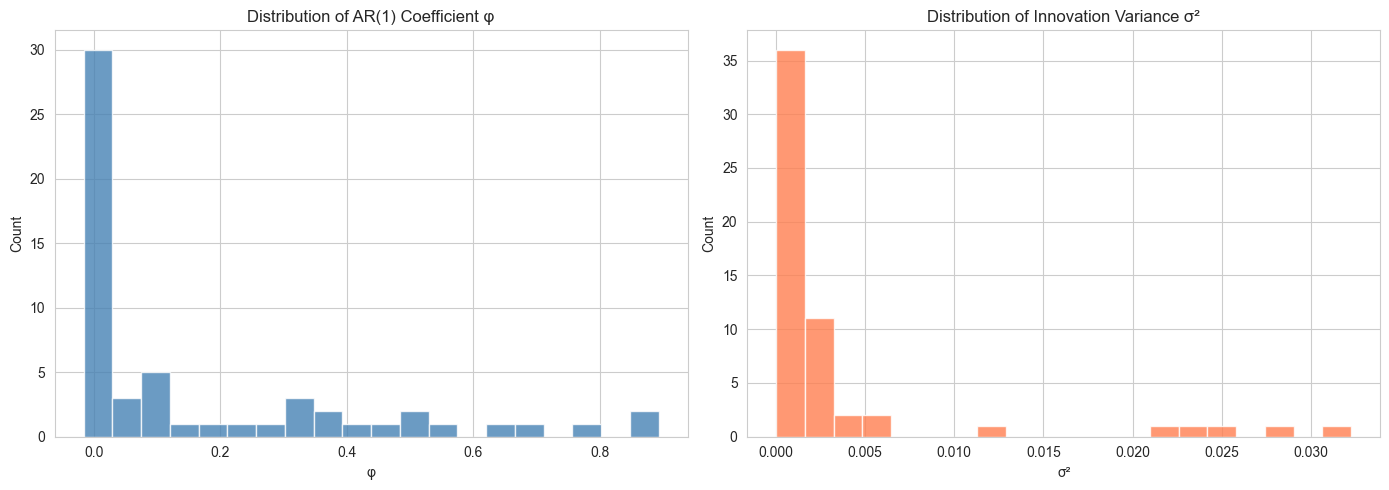

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_phi, bins=20, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution of AR(1) Coefficient φ")
axes[0].set_xlabel("φ")
axes[0].set_ylabel("Count")

axes[1].hist(all_sigma2, bins=20, color="coral", alpha=0.8, edgecolor="white")
axes[1].set_title("Distribution of Innovation Variance σ²")
axes[1].set_xlabel("σ²")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 10. End-to-End Generation Procedure

Given a horizon $T$:
1. Compute future calendar features $\hat S_r(t)$.
2. Simulate shared factors $u_t$ from the VAR model.
3. Simulate latent AR persistence $v_{r,t}$ per region, clamped to $|v| \le$ `V_CLAMP`.
4. Apply a **running** bias correction using the conditional variance
   $\mathrm{Var}(v_t) = \phi^2\,\mathrm{Var}(v_{t-1}) + \sigma^2$ (starting from 0).
5. Adjust $\kappa_r$ upward to compensate for the variance the AR term adds,
   preventing double-counted overdispersion.
6. Compute $\mu_{r,t} = \exp\!\bigl(\hat a_r + \hat S_r(t) + u_t^\top \hat\lambda_r
   + v_{r,t} - \tfrac{1}{2}\mathrm{Var}(v_t)\bigr)$.
7. Draw $N_{r,t} \sim \mathrm{NegBin}(\mu_{r,t}, \kappa_r^{\mathrm{adj}})$.

In [23]:
def generate_orders(
    T: int,
    region_indices: list,
    all_params: np.ndarray,
    all_kappa: np.ndarray,
    all_alpha: np.ndarray,
    all_phi: np.ndarray,
    all_sigma2: np.ndarray,
    A_var: np.ndarray,
    Sigma_eta: np.ndarray,
    U_hat: np.ndarray,
    n_cal_features: int,
    n_fourier: int,
    period: int,
    rng: np.random.Generator,
    v_clamp: float = 2.0,
) -> np.ndarray:
    """
    Generates synthetic daily order counts for specified regions over T days.

    The latent AR state is hard-clamped to [-v_clamp, v_clamp] and the NB
    dispersion is adjusted upward to compensate for the variance the AR term
    adds, preventing the double-counted overdispersion that produces
    unrealistic spikes.

    Args:
        T (int): Number of days to generate.
        region_indices (list): Region indices (within the full panel) to generate.
        all_params (np.ndarray): NB-GLM parameters per region. Shape: (R_all, n_features).
        all_kappa (np.ndarray): NB size parameter (1/alpha) per region. Shape: (R_all,).
        all_alpha (np.ndarray): NB dispersion (alpha) per region. Shape: (R_all,).
        all_phi (np.ndarray): AR(1) coefficients per region. Shape: (R_all,).
        all_sigma2 (np.ndarray): AR(1) innovation variance (already damped). Shape: (R_all,).
        A_var (np.ndarray): VAR coefficient matrix. Shape: (K, K).
        Sigma_eta (np.ndarray): VAR innovation covariance. Shape: (K, K).
        U_hat (np.ndarray): Empirical factor scores for initialization. Shape: (T_data, K).
        n_cal_features (int): Number of calendar features in the design matrix.
        n_fourier (int): Number of Fourier harmonic pairs.
        period (int): Fourier period in days.
        rng (np.random.Generator): Random number generator.
        v_clamp (float): Absolute bound on the latent AR state.

    Returns:
        counts (np.ndarray): Synthetic order counts. Shape: (T, len(region_indices)).
    """
    K = A_var.shape[0]
    n_reg = len(region_indices)

    # 1) Calendar features for the generation horizon
    cal_df = build_calendar_features(T, n_fourier=n_fourier, period=period)
    X_cal = cal_df.values  # (T, n_cal_features)

    # 2) Simulate VAR factors
    u = np.zeros((T, K))
    init_idx = rng.integers(0, U_hat.shape[0])
    u[0] = U_hat[init_idx]

    L_eta = np.linalg.cholesky(Sigma_eta)
    for t in range(1, T):
        innovation = L_eta @ rng.standard_normal(K)
        u[t] = A_var @ u[t - 1] + innovation

    # 3) For each region, compute log-mu and draw counts
    counts = np.zeros((T, n_reg), dtype=int)

    for j, r in enumerate(region_indices):
        params_r = all_params[r]
        beta = params_r[0]  # intercept
        kappa_r = all_kappa[r]
        phi_r = all_phi[r]
        sigma2_r = all_sigma2[r]

        beta_cal = params_r[1:1 + n_cal_features]
        lambda_r = params_r[1 + n_cal_features:]

        # Seasonal + factor components (deterministic given u)
        seasonal = X_cal @ beta_cal       # (T,)
        factor_effect = u @ lambda_r      # (T,)

        # --- Latent AR persistence with clamping ---
        v = np.zeros(T)
        sigma_r = np.sqrt(sigma2_r)
        for t in range(1, T):
            v[t] = phi_r * v[t - 1] + sigma_r * rng.standard_normal()
            v[t] = np.clip(v[t], -v_clamp, v_clamp)

        # Running bias correction: use the conditional variance at each step
        # instead of the full stationary variance.
        # Var(v_t | v_{t-1}) grows from 0 toward σ²/(1-φ²).
        # The cumulative conditional variance is σ² * sum(φ^{2k}, k=0..t-1).
        cond_var = np.zeros(T)
        for t in range(1, T):
            cond_var[t] = phi_r**2 * cond_var[t - 1] + sigma2_r
        bias_correction = 0.5 * cond_var

        # --- Adjust kappa to avoid double-counting ---
        # The AR term adds multiplicative variance ≈ exp(σ²_v) - 1 on the
        # mean.  We compensate by increasing kappa so the NB contributes
        # proportionally less variance.
        stat_var = sigma2_r / max(1.0 - phi_r**2, 1e-6)
        extra_mult_var = np.expm1(stat_var)       # exp(σ²_v) - 1
        denominator = 1.0 - kappa_r * extra_mult_var
        if denominator > 0.1:
            kappa_adj = kappa_r / denominator
        else:
            kappa_adj = 1e6  # effectively Poisson — AR already covers dispersion

        # Log intensity (clipped to prevent numerical overflow in Poisson/NB)
        log_mu = beta + seasonal + factor_effect + v - bias_correction
        log_mu = np.clip(log_mu, -30, 30)
        mu = np.exp(log_mu)

        # Draw from NB with adjusted dispersion
        kappa_adj = max(kappa_adj, 0.01)
        if kappa_adj > 1e5:
            counts[:, j] = rng.poisson(np.maximum(mu, 1e-10))
        else:
            safe_mu = np.maximum(mu, 1e-10)
            p_param = kappa_adj / (kappa_adj + safe_mu)
            p_param = np.clip(p_param, 1e-10, 1.0 - 1e-10)
            counts[:, j] = rng.negative_binomial(kappa_adj, p_param)

    return counts

Generated counts shape: (387, 57) (T=387, R=57)
Total generated orders: 260,641,534,830,868
Mean daily count per region: 11815655053.76
Fraction of zeros: 0.789


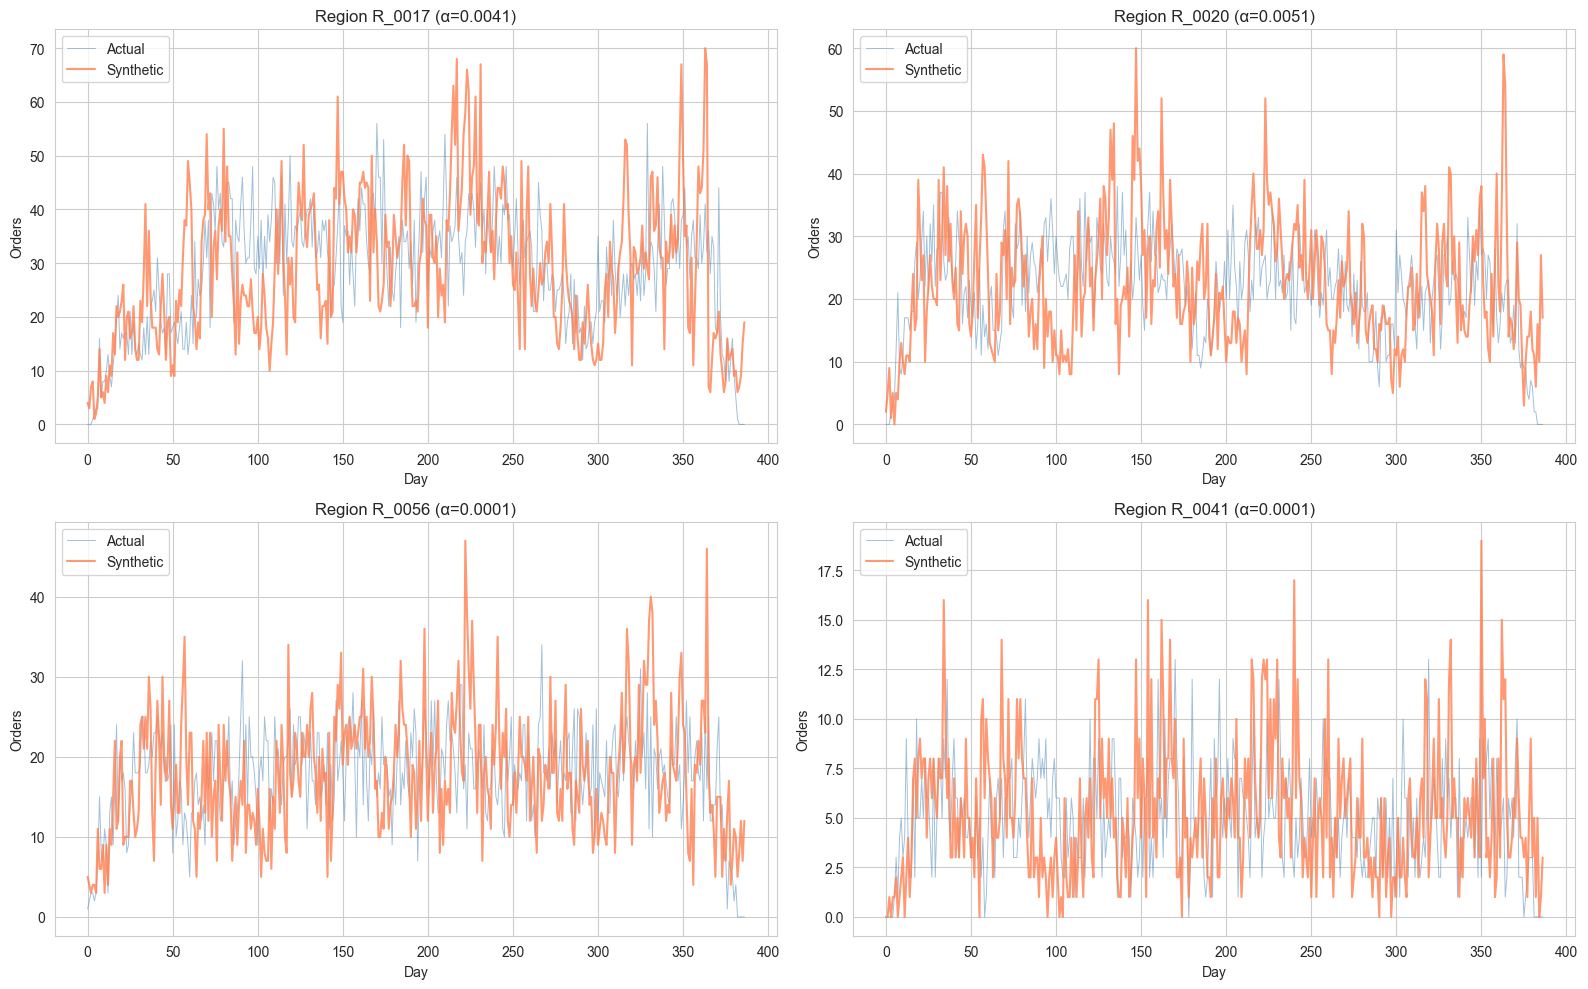

In [24]:
# Generate a sample for ALL regions
all_region_idx_list = list(range(R_all))

rng = np.random.default_rng(271)

synth_all = generate_orders(
    T=T_GENERATE,
    region_indices=all_region_idx_list,
    all_params=all_params,
    all_kappa=all_kappa,
    all_alpha=all_alpha,
    all_phi=all_phi,
    all_sigma2=all_sigma2,
    A_var=A_var,
    Sigma_eta=Sigma_eta,
    U_hat=U_hat,
    n_cal_features=n_cal_features,
    n_fourier=N_FOURIER_HARMONICS,
    period=FOURIER_PERIOD,
    rng=rng,
    v_clamp=V_CLAMP,
)

print(f"Generated counts shape: {synth_all.shape} (T={T_GENERATE}, R={R_all})")
print(f"Total generated orders: {synth_all.sum():,}")
print(f"Mean daily count per region: {synth_all.mean():.2f}")
print(f"Fraction of zeros: {(synth_all == 0).mean():.3f}")

# Quick visual comparison: top regions
# Ensure we compare on the same time axis
T_plot = min(counts_panel.shape[0], synth_all.shape[0])

# Set top_regions (based on region_means you already computed)
n_top = 4
top_regions = np.argsort(region_means)[::-1][:n_top]

ncols = 2  # set to 3 if you want 3 columns
nrows = (n_top + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)  # handle n_top=1

for i, r in enumerate(top_regions):
    ax = axes[i // ncols, i % ncols]
    ax.plot(counts_panel[:T_plot, r], alpha=0.5, linewidth=0.7, label="Actual", color="steelblue")
    ax.plot(synth_all[:T_plot, r], alpha=0.8, linewidth=1.5, label="Synthetic", color="coral")
    ax.set_title(f"Region {all_region_ids[r]} (α={all_alpha[r]:.4f})")
    ax.set_xlabel("Day")
    ax.set_ylabel("Orders")
    ax.legend()

# Hide unused subplots when n_top doesn't fill the grid
for j in range(len(top_regions), nrows * ncols):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

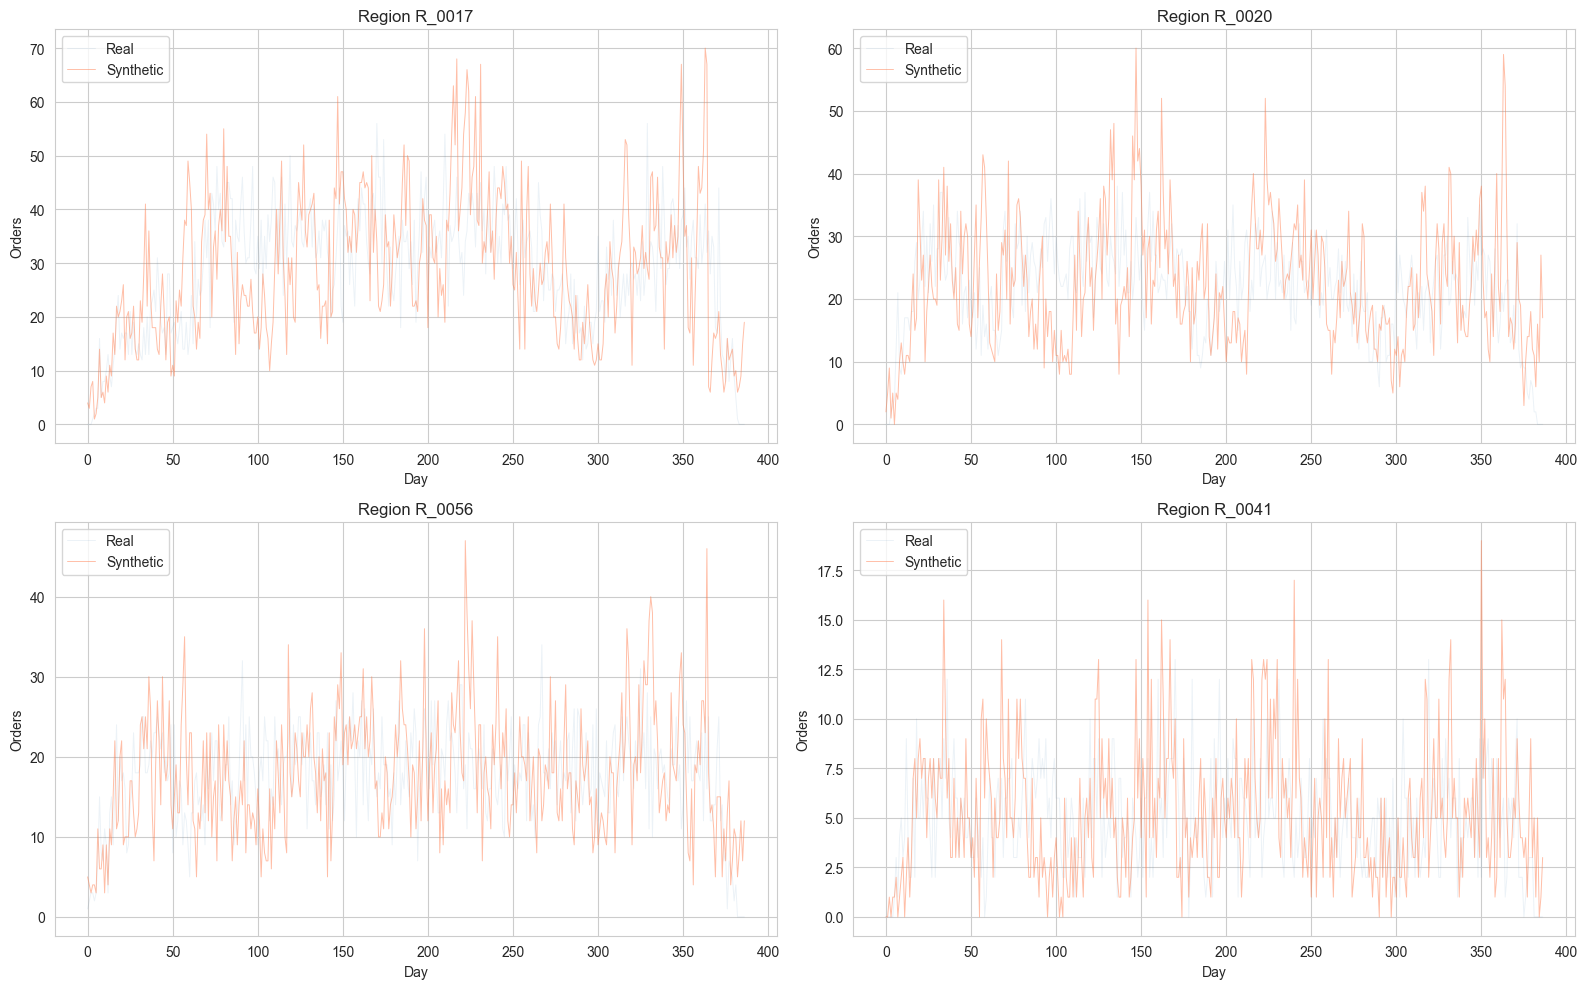

In [25]:
# Quick visual comparison: top regions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, r in enumerate(top_regions):
    ax = axes[i // 2, i % 2]
    ax.plot(counts_panel[:, r], alpha=0.1, linewidth=0.7, label="Real", color="steelblue")
    ax.plot(synth_all[:, r], alpha=0.5, linewidth=0.7, label="Synthetic", color="coral")
    ax.set_title(f"Region {all_region_ids[r]}")
    ax.set_xlabel("Day")
    ax.set_ylabel("Orders")
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Testing & Validation

We validate the generator by comparing real and synthetic data on:
1. Per-region mean and variance.
2. Weekday profiles.
3. Zero rates and tail quantiles (95th / 99th percentile).
4. Cross-region correlation matrix.
5. Autocorrelation (ACF) per region.
6. Distribution of weekly totals.

We run these tests for **all regions** and separately for the **selected region subset**
from the distance generator.

In [26]:
def compute_diagnostics(counts: np.ndarray) -> dict:
    """
    Computes summary statistics for an order count panel.

    Args:
        counts (np.ndarray): Order count panel. Shape: (T, R).

    Returns:
        diagnostics (dict): Dictionary with keys 'means', 'vars', 'zero_rates',
                            'p95', 'p99', 'weekly_totals', 'corr_matrix'.
    """
    T, R = counts.shape
    means = counts.mean(axis=0)
    variances = counts.var(axis=0)
    zero_rates = (counts == 0).mean(axis=0)
    p95 = np.percentile(counts, 95, axis=0)
    p99 = np.percentile(counts, 99, axis=0)

    n_weeks = T // 7
    weekly = counts[:n_weeks * 7].reshape(n_weeks, 7, R).sum(axis=1)  # (n_weeks, R)
    weekly_totals = weekly.sum(axis=1)  # (n_weeks,)

    if R > 1:
        corr_matrix = np.corrcoef(counts.T)
    else:
        corr_matrix = np.array([[1.0]])

    return {
        "means": means,
        "vars": variances,
        "zero_rates": zero_rates,
        "p95": p95,
        "p99": p99,
        "weekly_totals": weekly_totals,
        "corr_matrix": corr_matrix,
    }

In [210]:
def compute_acf(series: np.ndarray, max_lag: int = 20) -> np.ndarray:
    """
    Computes the sample autocorrelation function up to max_lag.

    Args:
        series (np.ndarray): Time series. Shape: (T,).
        max_lag (int): Maximum lag.

    Returns:
        acf_values (np.ndarray): ACF values. Shape: (max_lag + 1,).
    """
    n = len(series)
    mean = series.mean()
    var = series.var()
    if var < 1e-10:
        return np.zeros(max_lag + 1)
    acf_vals = np.zeros(max_lag + 1)
    acf_vals[0] = 1.0
    for lag in range(1, max_lag + 1):
        if lag >= n:
            break
        acf_vals[lag] = np.mean((series[:n - lag] - mean) * (series[lag:] - mean)) / var
    return acf_vals

In [212]:
def run_validation(
    real_counts: np.ndarray,
    synth_counts: np.ndarray,
    region_labels: list,
    title_prefix: str = "",
) -> None:
    """
    Runs a full battery of visual and numerical comparisons between real and synthetic counts.

    Args:
        real_counts (np.ndarray): Real order count panel. Shape: (T_real, R).
        synth_counts (np.ndarray): Synthetic order count panel. Shape: (T_synth, R).
        region_labels (list): Region identifier labels. Length: R.
        title_prefix (str): Prefix for plot titles.

    Returns:
        None
    """
    diag_real = compute_diagnostics(real_counts)
    diag_synth = compute_diagnostics(synth_counts)
    R = real_counts.shape[1]

    # --- 1) Mean & Variance scatter ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} Real vs Synthetic", fontsize=14)

    max_mean = max(diag_real['means'].max(), diag_synth['means'].max()) * 1.1
    axes[0].scatter(diag_real['means'], diag_synth['means'], s=20, alpha=0.7, color="steelblue")
    axes[0].plot([0, max_mean], [0, max_mean], 'k--', alpha=0.4)
    axes[0].set_xlabel("Real mean")
    axes[0].set_ylabel("Synthetic mean")
    axes[0].set_title("Per-region Mean")

    max_var = max(diag_real['vars'].max(), diag_synth['vars'].max()) * 1.1
    axes[1].scatter(diag_real['vars'], diag_synth['vars'], s=20, alpha=0.7, color="coral")
    axes[1].plot([0, max_var], [0, max_var], 'k--', alpha=0.4)
    axes[1].set_xlabel("Real variance")
    axes[1].set_ylabel("Synthetic variance")
    axes[1].set_title("Per-region Variance")

    axes[2].scatter(diag_real['zero_rates'], diag_synth['zero_rates'], s=20, alpha=0.7, color="grey")
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[2].set_xlabel("Real zero rate")
    axes[2].set_ylabel("Synthetic zero rate")
    axes[2].set_title("Per-region Zero Rate")

    plt.tight_layout()
    plt.show()

    # --- 2) Weekday profiles ---
    T_r = real_counts.shape[0]
    T_s = synth_counts.shape[0]
    wd_real = np.arange(T_r) % 7
    wd_synth = np.arange(T_s) % 7

    wd_profile_real = np.array([real_counts[wd_real == d].sum(axis=0).mean() for d in range(7)])
    wd_profile_synth = np.array([synth_counts[wd_synth == d].sum(axis=0).mean() for d in range(7)])

    weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    fig, ax = plt.subplots(figsize=(8, 4))
    x_pos = np.arange(7)
    width = 0.35
    ax.bar(x_pos - width/2, wd_profile_real, width, label="Real", color="steelblue", alpha=0.8)
    ax.bar(x_pos + width/2, wd_profile_synth, width, label="Synthetic", color="coral", alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(weekday_names)
    ax.set_title(f"{title_prefix} Weekday Profile (avg orders per region)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- 3) Tail quantiles ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    max_p95 = max(diag_real['p95'].max(), diag_synth['p95'].max()) * 1.1
    axes[0].scatter(diag_real['p95'], diag_synth['p95'], s=20, alpha=0.7, color="steelblue")
    axes[0].plot([0, max_p95], [0, max_p95], 'k--', alpha=0.4)
    axes[0].set_xlabel("Real 95th pctl")
    axes[0].set_ylabel("Synthetic 95th pctl")
    axes[0].set_title(f"{title_prefix} 95th Percentile")

    max_p99 = max(diag_real['p99'].max(), diag_synth['p99'].max()) * 1.1
    axes[1].scatter(diag_real['p99'], diag_synth['p99'], s=20, alpha=0.7, color="coral")
    axes[1].plot([0, max_p99], [0, max_p99], 'k--', alpha=0.4)
    axes[1].set_xlabel("Real 99th pctl")
    axes[1].set_ylabel("Synthetic 99th pctl")
    axes[1].set_title(f"{title_prefix} 99th Percentile")

    plt.tight_layout()
    plt.show()

    # --- 4) Cross-region correlation ---
    if R > 1:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        im1 = axes[0].imshow(diag_real['corr_matrix'], vmin=-1, vmax=1, cmap="RdBu_r")
        axes[0].set_title(f"{title_prefix} Real Correlation")
        plt.colorbar(im1, ax=axes[0], fraction=0.046)

        im2 = axes[1].imshow(diag_synth['corr_matrix'], vmin=-1, vmax=1, cmap="RdBu_r")
        axes[1].set_title(f"{title_prefix} Synthetic Correlation")
        plt.colorbar(im2, ax=axes[1], fraction=0.046)

        plt.tight_layout()
        plt.show()

        # Correlation of upper-triangle entries
        triu_idx = np.triu_indices(R, k=1)
        corr_corr, _ = stats.pearsonr(diag_real['corr_matrix'][triu_idx],
                                       diag_synth['corr_matrix'][triu_idx])
        print(f"  Correlation of cross-region correlations: {corr_corr:.3f}")

    # --- 5) ACF comparison for top regions ---
    n_show = min(4, R)
    top_idx = np.argsort(diag_real['means'])[::-1][:n_show]

    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for i, r in enumerate(top_idx):
        acf_real = compute_acf(real_counts[:, r])
        acf_synth = compute_acf(synth_counts[:, r])
        lags = np.arange(len(acf_real))
        axes[i].bar(lags - 0.15, acf_real, width=0.3, label="Real", color="steelblue", alpha=0.8)
        axes[i].bar(lags + 0.15, acf_synth, width=0.3, label="Synthetic", color="coral", alpha=0.8)
        axes[i].set_title(f"ACF — {region_labels[r]}")
        axes[i].set_xlabel("Lag")
        if i == 0:
            axes[i].legend()
    plt.tight_layout()
    plt.show()

    # --- 6) Weekly totals distribution ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(diag_real['weekly_totals'], bins=20, alpha=0.6, label="Real", color="steelblue", density=True)
    ax.hist(diag_synth['weekly_totals'], bins=20, alpha=0.6, label="Synthetic", color="coral", density=True)
    ax.set_title(f"{title_prefix} Weekly Total Orders Distribution")
    ax.set_xlabel("Weekly total")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Numerical summary ---
    mean_corr, _ = stats.pearsonr(diag_real['means'], diag_synth['means'])
    var_corr, _ = stats.pearsonr(diag_real['vars'], diag_synth['vars'])
    zero_mae = np.mean(np.abs(diag_real['zero_rates'] - diag_synth['zero_rates']))

    print(f"\n{title_prefix} Summary:")
    print(f"  Mean correlation (real vs synth):     {mean_corr:.4f}")
    print(f"  Variance correlation (real vs synth): {var_corr:.4f}")
    print(f"  Zero rate MAE:                        {zero_mae:.4f}")
    print(f"  Real total: {real_counts.sum():,}  Synthetic total: {synth_counts.sum():,}")

### 11.1 Validation on All Regions

In [27]:
# Generate multiple synthetic runs and average diagnostics
synth_runs_all = []
for run in range(N_SYNTHETIC_RUNS):
    run_rng = np.random.default_rng(SEED + run)
    s = generate_orders(
        T=T_data,
        region_indices=all_region_idx_list,
        all_params=all_params,
        all_kappa=all_kappa,
        all_alpha=all_alpha,
        all_phi=all_phi,
        all_sigma2=all_sigma2,
        A_var=A_var,
        Sigma_eta=Sigma_eta,
        U_hat=U_hat,
        n_cal_features=n_cal_features,
        n_fourier=N_FOURIER_HARMONICS,
        period=FOURIER_PERIOD,
        rng=run_rng,
        v_clamp=V_CLAMP,
    )
    synth_runs_all.append(s)

print(f"Generated {N_SYNTHETIC_RUNS} synthetic runs for all {R_all} regions, each with T={T_data} days.")

Generated 10 synthetic runs for all 57 regions, each with T=387 days.


In [28]:
# Use the averaged synthetic panel for validation
synth_avg_all = np.mean(synth_runs_all, axis=0).round().astype(int)

# Also validate with a single sample (more realistic)
synth_single_all = synth_runs_all[0]

print("=" * 60)
print("VALIDATION — ALL REGIONS (single synthetic sample)")
print("=" * 60)
run_validation(
    real_counts=counts_panel,
    synth_counts=synth_single_all,
    region_labels=all_region_ids,
    title_prefix="[All Regions]",
)

VALIDATION — ALL REGIONS (single synthetic sample)


NameError: name 'run_validation' is not defined

### 11.2 Validation on Selected Region Subset

Test the quality of generation for only the subset of regions selected by the distance generator.
This reflects the actual use case: the order generator will produce data for the
selected network configuration.

In [ ]:
# Generate for the selected subset
synth_runs_subset = []
for run in range(N_SYNTHETIC_RUNS):
    run_rng = np.random.default_rng(SEED + 1000 + run)
    s = generate_orders(
        T=T_data,
        region_indices=region_indices,
        all_params=all_params,
        all_kappa=all_kappa,
        all_alpha=all_alpha,
        all_phi=all_phi,
        all_sigma2=all_sigma2,
        A_var=A_var,
        Sigma_eta=Sigma_eta,
        U_hat=U_hat,
        n_cal_features=n_cal_features,
        n_fourier=N_FOURIER_HARMONICS,
        period=FOURIER_PERIOD,
        rng=run_rng,
        v_clamp=V_CLAMP,
    )
    synth_runs_subset.append(s)

print(f"Generated {N_SYNTHETIC_RUNS} synthetic runs for {len(region_indices)} selected regions.")

In [ ]:
real_subset = counts_panel[:, region_indices]
synth_single_subset = synth_runs_subset[0]
subset_labels = [all_region_ids[i] for i in region_indices]

print("=" * 60)
print("VALIDATION — SELECTED REGIONS (single synthetic sample)")
print("=" * 60)
run_validation(
    real_counts=real_subset,
    synth_counts=synth_single_subset,
    region_labels=subset_labels,
    title_prefix="[Selected Regions]",
)

### 11.3 Robustness: Averaged Diagnostics Across Multiple Runs

In [ ]:
# Compute diagnostics across all runs for all regions
all_run_means = np.array([compute_diagnostics(s)["means"] for s in synth_runs_all])
all_run_zeros = np.array([compute_diagnostics(s)["zero_rates"] for s in synth_runs_all])

avg_synth_means = all_run_means.mean(axis=0)
std_synth_means = all_run_means.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

real_means = counts_panel.mean(axis=0)
axes[0].errorbar(real_means, avg_synth_means, yerr=2 * std_synth_means, fmt='o',
                  markersize=4, alpha=0.7, color="steelblue", ecolor="lightblue")
max_val = max(real_means.max(), avg_synth_means.max()) * 1.1
axes[0].plot([0, max_val], [0, max_val], 'k--', alpha=0.4)
axes[0].set_xlabel("Real mean")
axes[0].set_ylabel("Synthetic mean (avg ± 2σ)")
axes[0].set_title(f"Mean Across {N_SYNTHETIC_RUNS} Runs (All Regions)")

avg_synth_zeros = all_run_zeros.mean(axis=0)
std_synth_zeros = all_run_zeros.std(axis=0)
real_zeros = (counts_panel == 0).mean(axis=0)
axes[1].errorbar(real_zeros, avg_synth_zeros, yerr=2 * std_synth_zeros, fmt='o',
                  markersize=4, alpha=0.7, color="coral", ecolor="lightsalmon")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel("Real zero rate")
axes[1].set_ylabel("Synthetic zero rate (avg ± 2σ)")
axes[1].set_title(f"Zero Rate Across {N_SYNTHETIC_RUNS} Runs (All Regions)")

plt.tight_layout()
plt.show()

mean_corr_avg, _ = stats.pearsonr(real_means, avg_synth_means)
print(f"Averaged-mean correlation with real: {mean_corr_avg:.4f}")

### 11.4 Save Outputs

Save the fitted model parameters so the order generator can be used downstream
without re-fitting.

In [ ]:
# SAVE OUTPUTS

OUTPUTS_PATH = Path(OUTPUTS_PATH)
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

out_path = OUTPUTS_PATH / f"order_model_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"
np.savez(
    out_path,
    all_params=all_params,
    all_beta=all_beta,
    all_kappa=all_kappa,
    all_alpha=all_alpha,
    all_phi=all_phi,
    all_sigma2=all_sigma2,
    A_var=A_var,
    Sigma_eta=Sigma_eta,
    U_hat=U_hat,
    n_cal_features=np.array([n_cal_features]),
    n_fourier=np.array([N_FOURIER_HARMONICS]),
    period=np.array([FOURIER_PERIOD]),
    region_indices=np.array(region_indices),
    v_clamp=np.array([V_CLAMP]),
    ar_damping=np.array([AR_DAMPING]),
)

print(f"Saved to {out_path}")
print(f"  all_params:              {all_params.shape}")
print(f"  all_beta (intercept):     {all_beta.shape}")
print(f"  all_kappa:               {all_kappa.shape}")
print(f"  all_phi:                 {all_phi.shape}")
print(f"  A_var:                   {A_var.shape}")
print(f"  Sigma_eta:               {Sigma_eta.shape}")
print(f"  U_hat:                   {U_hat.shape}")
print(f"  region_indices: {len(region_indices)}")

## Step 4 — Demand: Number of Orders per Day (per region) — Count-calibrated Factor + Dynamic GLM

### Goal and data
You observe daily order counts per region:
- Counts: $N_{r,t}\in\{0,1,2,\dots\}$ for region $r=1,\dots,R$ and day $t=1,\dots,T$.

We want a generator that preserves:
1) Region-specific level (some regions systematically order more),  
2) Seasonality (weekday patterns + possible annual/weekly cycles),  
3) Cross-region co-movement (shared “demand climate” shocks),  
4) Region-specific persistence (local autocorrelation not explained by shared factors),  
5) Overdispersion typical for counts (Negative Binomial),  
6) Realistic zero rates and tails (often where log-Gaussian approximations drift).


## 4.0 Preprocessing choices

### A) Calendar covariates
Create day-level features such as:
- weekday indicators (Mon–Sun),
- month indicators (Jan–Dec) (Assume that day_id=0 is Jan 1),
- optional: Fourier terms for smooth annual seasonality (see below),
- optional: holiday / promo indicators (if available).

**Important note:** In this approach, we will fit seasonality inside a *count likelihood* model (Negative Binomial with log link), so we do not need to log-transform $N_{r,t}$ for the seasonality regression.

### B) Optional transform for factor extraction only
If you want PCA-based factor extraction (Step 4.2–4.3), use a variance-stabilizing transform **only for the factor estimation step**, not for the final likelihood:
- $y_{r,t}=\log\!\bigl(N_{r,t}+c\bigr)$ with $c\in\{0.5,1\}$.

This is used to estimate shared latent factors robustly; the final generator still uses NB counts.


## 4.1 Estimate seasonality inside a Negative Binomial mean model

We model counts with a log-link:
- $N_{r,t}\sim \mathrm{NegBin}(\mu_{r,t},\kappa_r)$
- $\log \mu_{r,t}= \ell_{r,t}$

Seasonality enters additively in the linear predictor $\ell_{r,t}$.

### Region-specific seasonality (weekday dummies + month + optional Fourier)
For each region $r$, define deterministic seasonal terms:

$$
S_r(t)=\sum_{d=1}^{6}\gamma_{r,d}\,\mathbb{1}\{\text{weekday}(t)=d\}
+ \sum_{m=1}^{11}\lambda_{r,m}\,\mathbb{1}\{\text{month}(t)=m\}
+ \sum_{h=1}^{H}\left[\alpha_{r,h}\sin\!\left(\frac{2\pi h t}{P}\right)+\delta_{r,h}\cos\!\left(\frac{2\pi h t}{P}\right)\right]
$$

Notes:
- Use one weekday and one month as reference categories.
- Implement first without Fourier terms and then add them optionally.
- Choose $P=365$ (daily data) and keep $H$ small (e.g., $H=1,2,3$), selecting via AIC/BIC or rolling validation.
- If you have only $T=385$ days, keep annual Fourier terms conservative (they may be weakly identified).

We will estimate coefficients $\gamma_{r,\cdot},\lambda_{r,\cdot},\alpha_{r,\cdot},\delta_{r,\cdot}$ within the NB regression (Step 4.4 / Step 4.5 below).  
For bookkeeping, you can still refer to $\hat S_r(t)$ as the fitted seasonal component.


## 4.2 Build a shared-factor panel for co-movement (factor extraction)

We want a low-dimensional “demand climate” time series that drives multiple regions together.

### A) Construct a seasonality-adjusted panel (for PCA only)
Compute a transformed panel for factor extraction:
- $y_{r,t} = \log(N_{r,t}+c)$

Then remove a simple deterministic seasonal fit to avoid PCA soaking up weekday effects.
A practical approach:
- Fit a *light* regression of $y_{r,t}$ on weekday/month (and optional Fourier) using OLS per region
- Compute residuals $\tilde y_{r,t}$ from that regression
- Stack into $\tilde Y\in\mathbb{R}^{T\times R}$

**Note:** This step is only to obtain stable factors; the final model is NB.

### B) Standardization (recommended)
Standardize columns before PCA so high-variance regions don’t dominate:
- $\tilde y^{\text{std}}_{r,t} = \frac{\tilde y_{r,t}-\bar{\tilde y}_r}{s_r}$

Store $(\bar{\tilde y}_r,s_r)$ for later interpretation only; the NB model will be fitted separately.


## 4.3 Extract shared latent factors $u_t$ and loadings $\beta_r$ via PCA

Run PCA on $\tilde Y$ (or standardized $\tilde Y$).

Choose $K$ factors (e.g., via explained variance / scree plot).

You obtain an approximation:
- $\tilde y_{r,t} \approx u_t^\top \beta_r + e_{r,t}$

where:
- $u_t \in \mathbb{R}^K$ is the time-varying common factor vector (“demand climate”),
- $\beta_r \in \mathbb{R}^K$ are region loadings,
- $e_{r,t}$ is an idiosyncratic remainder.

After estimation, you have $\hat u_t$ and $\hat\beta_r$.

**Practical note:** PCA factors are identified up to rotation/sign. Keep the fitted $\hat u_t$ and use it consistently through the remaining steps.


## 4.4 Model factor dynamics: VAR(1) (or VAR(p))

To simulate the latent-factor process and preserve autocorrelation, fit a VAR on $\hat u_t$.

Baseline VAR(1):
- $\hat u_t = A\,\hat u_{t-1} + \eta_t$
- $\eta_t \sim \mathcal N(0,\Sigma_\eta)$

If needed, extend to VAR($p$) using AIC/BIC.

Generation step:
- $u_t = A\,u_{t-1} + \eta_t$

Initialization:
- draw $u_1$ from the empirical distribution of $\hat u_t$, or
- sample from the stationary distribution implied by $(A,\Sigma_\eta)$ (if stable).

**Interpretation:** This generates shared “climate shocks” that move multiple regions together.


## 4.5 Fit the count mapping (core difference): Negative Binomial GLM per region

This is the key departure from a purely log-Gaussian reconstruction: we fit the mapping from factors + seasonality to *counts* using a Negative Binomial likelihood.

For each region $r$, fit:

- $N_{r,t}\sim \mathrm{NegBin}(\mu_{r,t},\kappa_r)$
- $\log \mu_{r,t} = a_r + S_r(t) + \hat u_t^\top \lambda_r$

where:
- $a_r$ is a region intercept (baseline log-intensity),
- $S_r(t)$ is the region-specific deterministic seasonality (weekday/month/Fourier),
- $\lambda_r\in\mathbb{R}^K$ are region-specific factor coefficients (how the region responds to demand climate),
- $\kappa_r$ is a region-specific NB dispersion.

**Why this step matters:**
- It uses the appropriate likelihood for counts (handles zeros and overdispersion),
- It calibrates the factor impact directly on the count scale via the log link,
- It reduces bias from exponentiating Gaussian residuals.

Implementation notes:
- Fit via MLE (standard NB-GLM).
- If many regions have excess zeros beyond NB, consider a Zero-Inflated NB as a diagnostic upgrade (optional).


## 4.6 Region-specific persistence beyond factors (choose one)

We want autocorrelation not fully explained by factors.

### Option A (recommended): NB-INGARCH / observation-driven dynamic GLM
Model the linear predictor with a persistence term that depends on past counts and/or past mean:

$$
\log \mu_{r,t}
=
a_r + S_r(t) + u_t^\top \lambda_r
+ \alpha_r \log(N_{r,t-1}+1)
+ \beta_r \log(\mu_{r,t-1})
$$

Notes:
- This preserves persistence in a count-consistent way.
- Keep it simple (often $\alpha_r,\beta_r$ shared across regions or partially pooled to avoid overfitting).

### Option B (simpler, close to your original): AR on a latent additive term in the linear predictor
Add an idiosyncratic latent component $v_{r,t}$:

- $v_{r,t} = \phi_r v_{r,t-1} + \epsilon_{r,t}$  
- $\epsilon_{r,t}\sim\mathcal N(0,\sigma_r^2)$

and define:
- $\log\mu_{r,t} = a_r + S_r(t) + u_t^\top \lambda_r + v_{r,t}$

This is easy to simulate and often works, but it reintroduces a log-Gaussian latent term.
If you use Option B, validate that it does not inflate means/tails; apply a small bias correction if needed (see Note below).

**Note (bias correction for Option B):**
If $v_{r,t}$ adds Gaussian variance, you may correct mean inflation by:
- $\mu_{r,t} = \exp(\ell_{r,t} - \tfrac12 \mathrm{Var}(v_{r,t}))$
where $\ell_{r,t}$ is the linear predictor without the correction.
Use this only if you observe systematic over-generation of counts.


## 4.7 Reconstruct the log-intensity and convert to mean counts

During generation, for each region/day:

- $\log \mu_{r,t} = \hat a_r + \hat S_r(t) + u_t^\top \hat\lambda_r$  (plus persistence terms from 4.6 if used)

Then:
- $\mu_{r,t} = \exp\!\bigl(\log \mu_{r,t}\bigr)$


## 4.8 Negative Binomial parameterization and dispersion $\kappa_r$

Use the NB parameterization in terms of mean $\mu_{r,t}$ and dispersion $\kappa_r$:

- $\mathbb{E}[N_{r,t}]=\mu_{r,t}$
- $\mathrm{Var}(N_{r,t})=\mu_{r,t}+\frac{\mu_{r,t}^2}{\kappa_r}$

Interpretation:
- large $\kappa_r$ $\rightarrow$ close to Poisson,
- small $\kappa_r$ $\rightarrow$ strong overdispersion.

Estimate $\kappa_r$ jointly in the NB-GLM fit (Step 4.5), or by profiling MLE given fitted $\mu_{r,t}$.

**Distribution choice diagnostics:**
- If $\mathrm{Var}(N_{r,t}) \approx \mathbb{E}[N_{r,t}]$ and zeros are not excessive, Poisson may suffice.
- If NB still underfits zeros, consider Zero-Inflated NB (optional).
- Prefer NB over ad-hoc Gaussian noise on $\log(N+c)$ when zeros/tails matter.


## 4.9 Generation procedure (end-to-end)

Given a horizon $T$:

1) Compute future deterministic seasonality $\hat S_r(t)$ for each future day $t=1,\dots,T$.  
2) Simulate shared factors $u_t$ from the fitted VAR model.  
3) If using persistence:
   - Option A (NB-INGARCH): simulate recursively using generated $N_{r,t-1}$ and/or $\mu_{r,t-1}$.  
   - Option B (latent AR): simulate $v_{r,t}$ for each region.  
4) Compute $\mu_{r,t}=\exp\!\bigl(\hat a_r+\hat S_r(t)+u_t^\top\hat\lambda_r \;(+\;v_{r,t}\text{ or INGARCH terms})\bigr)$.  
5) Draw counts $N_{r,t}\sim \mathrm{NegBin}\!\bigl(\mu_{r,t},\kappa_r\bigr)$.  
6) (Optional validation) Compare real vs synthetic on:
   - per-region mean/variance and weekday profiles,
   - zero rates and tail quantiles (e.g., 95th/99th),
   - cross-region correlation matrix,
   - ACF per region, distribution of weekly totals,
   - regime behavior if applicable (holiday spikes).


## 4.10 Summary of differences vs. a log-Gaussian reconstruction approach

- Factors ($u_t$) can still be extracted with PCA on log-stabilized counts.
- The critical change is that the mapping from (seasonality + factors + persistence) to counts is fitted with a **Negative Binomial GLM** (count likelihood), rather than treating the process as Gaussian in $\log(N+c)$ and only applying NB at the end.
- This tends to better preserve:
  - zero rates,
  - overdispersion,
  - tail behavior,
  - and avoids mean inflation from exponentiating Gaussian residual noise.